# EDA Definitivo — GeoVision-CLIP Cali

**Propósito**: documentación exploratoria final del panel analítico del proyecto, justificando cada decisión técnica con evidencia visual y estadística.

**Estructura**:
1. Setup y datos
2. ¿Por qué este BBox?
3. DAGMA — ground truth
4. Sentinel-5P — gases atmosféricos
5. ERA5 — meteorología
6. Tiles: comparación rescate-1500 vs originales vs v3
7. ¿Por qué los rangos NDVI/NDBI elegidos?
8. Cobertura del rescate-1500
9. Resumen ejecutivo

**Ejecución**: local, no requiere GPU. Usa los datos descargados de HuggingFace en `data/`.

## 1. Setup y carga de datos

Cargo las 4 fuentes principales:
- **DAGMA limpio** (ground truth de concentraciones, 2021-2024 horario)
- **Sentinel-5P** NO2, SO2, O3 (paneles Zarr, gases atmosféricos)
- **ERA5 hourly** (meteorología: viento, BLH, temperatura)
- **Tiles rescate-1500** (dataset Sit 2 final)

Para comparación posterior cargo también los datasets antiguos (`originales_meta.parquet`, `v3_meta.parquet`) que vienen de Kaggle.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

ROOT = Path('/home/yeigen/Documents/proyecto-3')
DATA = ROOT / 'data'
OUT = ROOT / 'docs' / 'situacion-1'
OUT.mkdir(parents=True, exist_ok=True)

BBOX = (-76.65, 3.30, -76.30, 3.65)  # del config.py — área metropolitana Cali + Yumbo + corredor caña
print(f'BBox proyecto: {BBOX}')
print(f'Datos en: {DATA}')
print(f'Output: {OUT}')

BBox proyecto: (-76.65, 3.3, -76.3, 3.65)
Datos en: /home/yeigen/Documents/proyecto-3/data
Output: /home/yeigen/Documents/proyecto-3/docs/situacion-1


In [2]:
df_dagma = pd.read_parquet(DATA / 'dagma' / 'df_dagma_unificado_coordenadas_limpias.parquet')
df_dagma['fecha'] = pd.to_datetime(df_dagma['fecha'])
df_est = pd.read_csv(DATA / 'dagma' / 'estaciones_metadata.csv')

print(f'DAGMA: {len(df_dagma):,} filas | {df_dagma.nombre_est.nunique()} estaciones | {df_dagma.tipo_gas.nunique()} gases')
print(f'Rango: {df_dagma.fecha.min()} → {df_dagma.fecha.max()}')
print(f'Columnas: {list(df_dagma.columns)}')

DAGMA: 300,025 filas | 9 estaciones | 3 gases
Rango: 2021-01-01 00:00:00 → 2024-12-31 23:00:00
Columnas: ['nombre_est', 'tipo_gas', 'concentracion', 'fecha', 'fuente', 'estacion_id', 'latitud', 'longitud', 'altitud', 'municipio', 'era5_temperature_2m', 'era5_dewpoint_temperature_2m', 'era5_u_component_of_wind_10m', 'era5_v_component_of_wind_10m', 'era5_boundary_layer_height', 'era5_relative_humidity_850hPa', 'era5_surface_pressure', 'era5_total_precipitation', 'modis_Optical_Depth_047', 'modis_Optical_Depth_055', 'modis_Column_WV', 'modis_AOD_QA', 'temperatura_c', 'dewpoint_c', 'precipitacion_mm', 'latitud_original', 'longitud_original', 'altitud_original', 'tipo_gas_id']


In [3]:
ds_no2 = xr.open_zarr(DATA / 'copernicus_s5p_offl_l3_no2' / 'panel.zarr', consolidated=False)
ds_so2 = xr.open_zarr(DATA / 'copernicus_s5p_offl_l3_so2' / 'panel.zarr', consolidated=False)
ds_o3  = xr.open_zarr(DATA / 'copernicus_s5p_offl_l3_o3'  / 'panel.zarr', consolidated=False)
ds_era5 = xr.open_zarr(DATA / 'ecmwf_era5_hourly' / 'panel.zarr', consolidated=False)

print(f'S5P NO2: {dict(ds_no2.sizes)}')
print(f'S5P SO2: {dict(ds_so2.sizes)}')
print(f'S5P O3:  {dict(ds_o3.sizes)}')
print(f'ERA5:    {dict(ds_era5.sizes)}')

S5P NO2: {'time': 25592, 'band': 3, 'y': 36, 'x': 36}
S5P SO2: {'time': 25829, 'band': 2, 'y': 36, 'x': 36}
S5P O3:  {'time': 25716, 'band': 2, 'y': 36, 'x': 36}
ERA5:    {'time': 43824, 'band': 8, 'y': 2, 'x': 2}


In [4]:
df_rescate = pd.read_parquet(DATA / 'tiles' / 'rescate-1500' / 'tiles_meta.parquet')
df_orig    = pd.read_parquet(DATA / 'tiles' / 'comparacion' / 'originales_meta.parquet')
df_v3      = pd.read_parquet(DATA / 'tiles' / 'comparacion' / 'v3_meta.parquet')

for nombre, df in [('rescate-1500', df_rescate), ('originales (5000)', df_orig), ('v3 (1150)', df_v3)]:
    print(f'{nombre:20s} n={len(df):5d} | clases={dict(df.clase.value_counts())}')

rescate-1500         n= 1500 | clases={'contaminacion_alta_NO2': np.int64(300), 'contaminacion_alta_SO2': np.int64(300), 'ozono_anomalo': np.int64(300), 'vegetacion_densa': np.int64(300), 'suelo_urbano': np.int64(300)}
originales (5000)    n= 5000 | clases={'contaminacion_alta_NO2': np.int64(1000), 'contaminacion_alta_SO2': np.int64(1000), 'ozono_anomalo': np.int64(1000), 'vegetacion_densa': np.int64(1000), 'suelo_urbano': np.int64(1000)}
v3 (1150)            n= 1150 | clases={'contaminacion_alta_NO2': np.int64(230), 'vegetacion_densa': np.int64(230), 'ozono_anomalo': np.int64(230), 'suelo_urbano': np.int64(230), 'contaminacion_alta_SO2': np.int64(230)}


## 2. ¿Por qué este BBox?

**BBox**: `[-76.65°, 3.30°, -76.30°, 3.65°]` (definido en `google-earth/config.py`).

**Razón**:
- Cubre área metropolitana de Cali (~38 × 38 km)
- Incluye el corredor industrial Yumbo-Acopi al norte (emisor de SO2)
- Incluye zona de cultivos de caña de azúcar (emisor de SO2 por quemas)
- Contiene las 10 estaciones de monitoreo DAGMA/CVC con margen ≥0.05° al borde

Verifico abajo que todas las estaciones están dentro:

In [5]:
lon_min, lat_min, lon_max, lat_max = BBOX
df_est['en_bbox'] = df_est.apply(
    lambda r: (lon_min <= r.longitud <= lon_max) and (lat_min <= r.latitud <= lat_max),
    axis=1
)
df_est['dist_borde_lat_grados'] = df_est.apply(
    lambda r: min(r.latitud - lat_min, lat_max - r.latitud), axis=1
)
df_est['dist_borde_lon_grados'] = df_est.apply(
    lambda r: min(r.longitud - lon_min, lon_max - r.longitud), axis=1
)
print(df_est[['nombre_est','latitud','longitud','en_bbox','dist_borde_lat_grados','dist_borde_lon_grados']].round(4).to_string(index=False))
print(f'\nEstaciones dentro del BBox: {df_est.en_bbox.sum()}/{len(df_est)}')

    nombre_est  latitud  longitud  en_bbox  dist_borde_lat_grados  dist_borde_lon_grados
    base aerea   3.4571  -76.5023     True                 0.1571                 0.1477
  canaveralejo   3.4111  -76.5444     True                 0.1111                 0.1056
     compartir   3.4258  -76.4741     True                 0.1258                 0.1741
  era - obrero   3.4525  -76.5222     True                 0.1525                 0.1278
        ermita   3.4533  -76.5311     True                 0.1533                 0.1189
estacion yumbo   3.5791  -76.4896     True                 0.0709                 0.1604
         flora   3.4792  -76.5072     True                 0.1708                 0.1428
         pance   3.3214  -76.5333     True                 0.0214                 0.1167
      univalle   3.3768  -76.5336     True                 0.0768                 0.1164

Estaciones dentro del BBox: 9/9


## 3. DAGMA — Ground truth de calidad del aire

**¿Qué es?**: red de monitoreo terrestre del DAGMA (Departamento Administrativo de Gestión del Medio Ambiente) de Cali + CVC (Corporación Autónoma Regional del Valle del Cauca). Mide concentraciones horarias de NO2, SO2 y O3 en superficie.

**¿Por qué este parquet limpio y no el raw?**
1. Coordenadas verificadas y corregidas (la versión raw tenía inconsistencias de ~1-2 km)
2. Unificación con ERA5 (8 variables meteorológicas) y MODIS AOD (3 variables) por fecha-estación
3. Filtrado a 2021-2024 (overlap temporal con Sentinel-5P operacional)

**Limitación documentada**: NO2 sólo medido en 2 estaciones (Universidad del Valle, Yumbo). SO2 en 5. O3 en 7. Esto restringe LOO-CV de Sit 3.

In [6]:
cov_gas = df_dagma.groupby('tipo_gas').agg(
    n_estaciones=('nombre_est', 'nunique'),
    n_obs=('concentracion', 'size'),
    n_validos=('concentracion', lambda s: s.notna().sum()),
    media=('concentracion', 'mean'),
    std=('concentracion', 'std'),
    p50=('concentracion', 'median'),
    p95=('concentracion', lambda s: s.quantile(0.95)),
).round(2)
print('=== Cobertura por gas ===')
print(cov_gas)

=== Cobertura por gas ===
          n_estaciones   n_obs  n_validos  media    std    p50    p95
tipo_gas                                                             
no2                  2   23604      23604  11.35   7.68  10.10  26.51
o3                   7  167592     167592  20.43  20.72  12.16  68.43
so2                  5  108829     108829   3.63   3.66   2.54  11.28


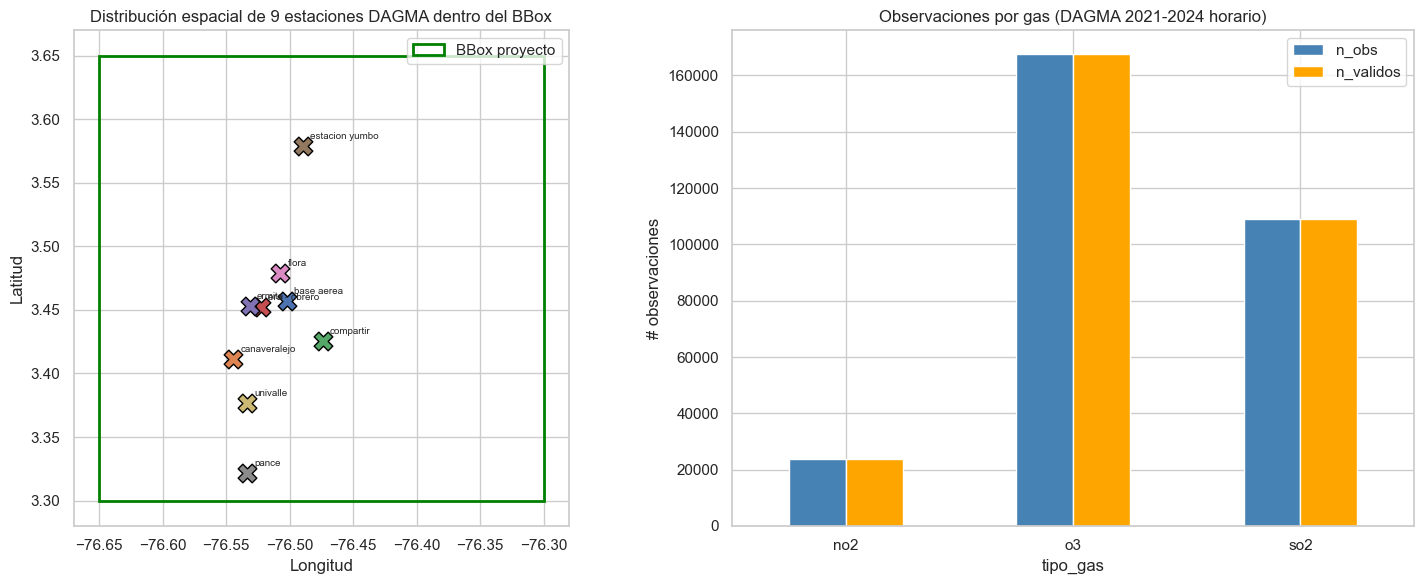

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Mapa: estaciones DAGMA dentro del BBox
ax = axes[0]
ax.add_patch(Rectangle((lon_min, lat_min), lon_max-lon_min, lat_max-lat_min,
                       fill=False, edgecolor='green', linewidth=2, label='BBox proyecto'))
for _, r in df_est.iterrows():
    ax.scatter(r.longitud, r.latitud, marker='X', s=180, edgecolor='black', linewidth=1)
    ax.annotate(r.nombre_est, (r.longitud, r.latitud), fontsize=7, xytext=(5,5), textcoords='offset points')
ax.set_xlim(lon_min - 0.02, lon_max + 0.02)
ax.set_ylim(lat_min - 0.02, lat_max + 0.02)
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.set_title('Distribución espacial de 9 estaciones DAGMA dentro del BBox')
ax.set_aspect('equal'); ax.legend()

# Conteo obs por gas
ax = axes[1]
cov_gas[['n_obs','n_validos']].plot(kind='bar', ax=ax, color=['steelblue','orange'])
ax.set_title('Observaciones por gas (DAGMA 2021-2024 horario)')
ax.set_ylabel('# observaciones')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(OUT / 'dagma_cobertura.png', dpi=140, bbox_inches='tight')
plt.show()

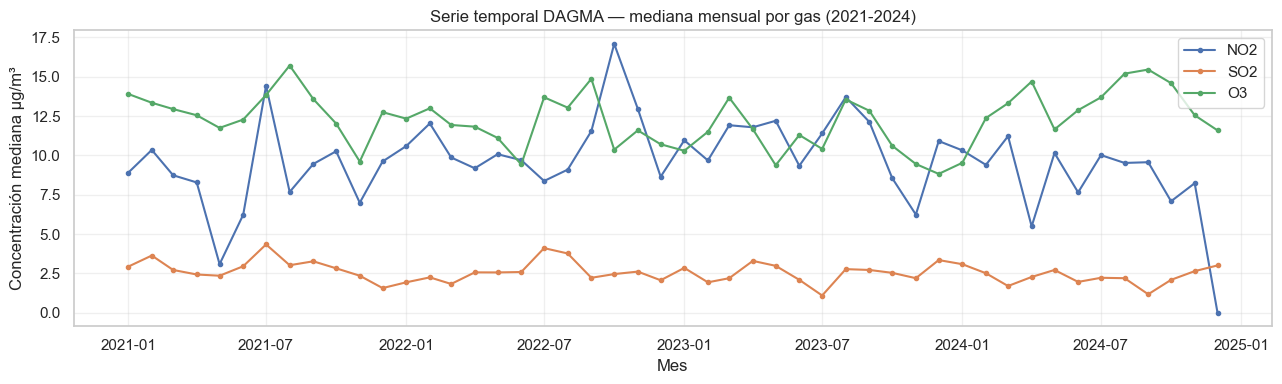

In [8]:
df_dagma['mes'] = df_dagma.fecha.dt.to_period('M').dt.to_timestamp()
serie_mes = df_dagma.groupby(['mes', 'tipo_gas']).concentracion.median().reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
for gas in ['no2', 'so2', 'o3']:
    sub = serie_mes[serie_mes.tipo_gas == gas]
    ax.plot(sub.mes, sub.concentracion, marker='o', markersize=3, label=gas.upper())
ax.set_xlabel('Mes'); ax.set_ylabel('Concentración mediana µg/m³')
ax.set_title('Serie temporal DAGMA — mediana mensual por gas (2021-2024)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'dagma_serie_temporal.png', dpi=140, bbox_inches='tight')
plt.show()

## 4. Sentinel-5P — Gases atmosféricos en columna troposférica

**¿Qué mide?**: TROPOMI (instrumento a bordo de Sentinel-5P) mide columnas troposféricas de NO2, SO2 y O3 cada día desde órbita polar a 824 km de altitud. Resolución nativa 3.5 × 5.5 km, 1-2 órbitas/día sobre Cali.

**¿Por qué incluirlo?**:
- Es la **única observación directa de gases** sobre Cali (Sentinel-2 ve sólo superficie)
- Cobertura espacial completa de la ciudad (no solo donde hay estaciones)
- Usado como pseudo-label para Sit 2 (cuantiles por clase) y como input al Kriging de Sit 3

**¿Por qué resolución 36×36 en el panel?**: el panel Zarr re-muestrea a una grilla regular de ~0.01° dentro del BBox para alinear con S2 (10 m) y ERA5 (9 km).

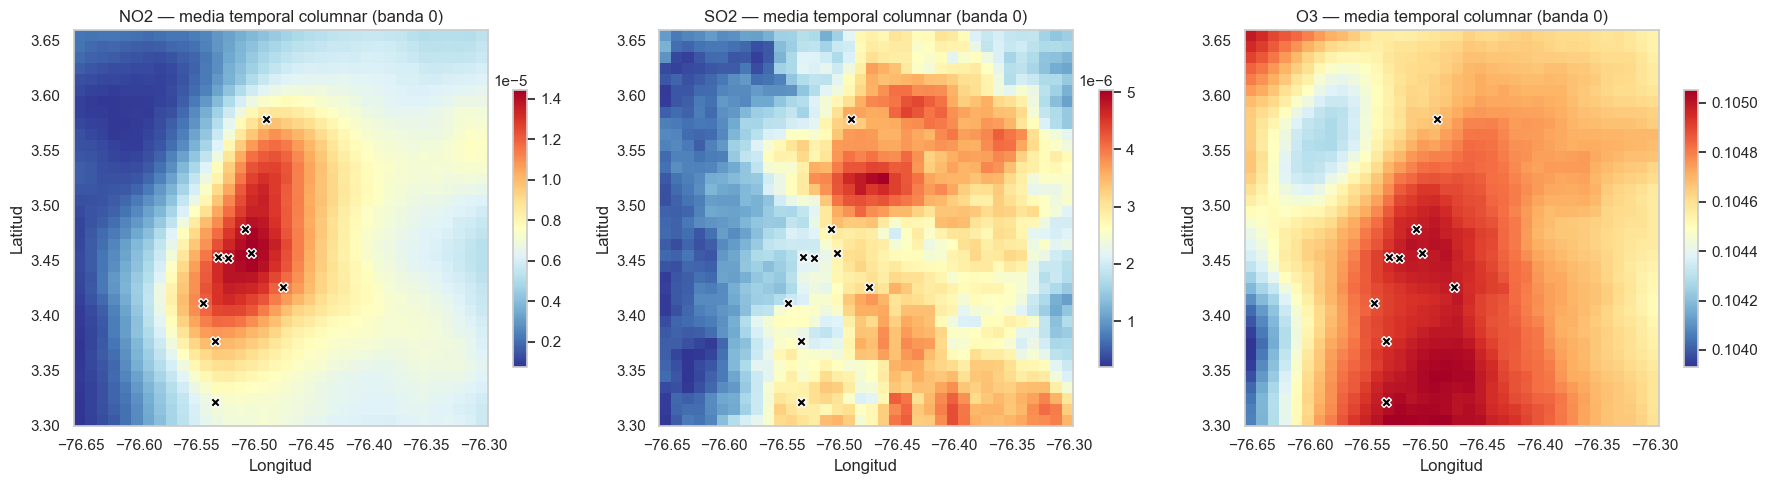

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, ds, gas, vmax in [
    (axes[0], ds_no2, 'NO2', None),
    (axes[1], ds_so2, 'SO2', None),
    (axes[2], ds_o3,  'O3',  None),
]:
    arr = ds['data'].isel(band=0).mean('time').values
    im = ax.pcolormesh(ds.x, ds.y, arr, cmap='RdYlBu_r', shading='auto')
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.scatter(df_est.longitud, df_est.latitud, marker='X', c='black', s=50, edgecolor='white')
    ax.set_title(f'{gas} — media temporal columnar (banda 0)')
    ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
plt.tight_layout()
plt.savefig(OUT / 's5p_mapas_medios.png', dpi=140, bbox_inches='tight')
plt.show()

In [10]:
def parse_time_granule(time_values):
    """Convierte ndarray de fechas (granule ID str o datetime64) a DatetimeIndex."""
    arr = np.asarray(time_values)
    if arr.dtype.kind == 'M':
        return pd.DatetimeIndex(arr)
    fechas = []
    for v in arr:
        s = str(v)
        try:
            f = pd.Timestamp(f'{s[:4]}-{s[4:6]}-{s[6:8]}T{s[9:11]}:{s[11:13]}:{s[13:15]}')
        except Exception:
            try:
                f = pd.Timestamp(f'{s[:4]}-{s[4:6]}-{s[6:8]}')
            except Exception:
                f = pd.NaT
        fechas.append(f)
    return pd.DatetimeIndex(fechas)

fechas_no2 = parse_time_granule(ds_no2.time.values)
fechas_so2 = parse_time_granule(ds_so2.time.values)
fechas_o3  = parse_time_granule(ds_o3.time.values)

tabla = pd.DataFrame([
    {'fuente': 'NO2', 'n_obs': len(fechas_no2), 'inicio': fechas_no2.min(), 'fin': fechas_no2.max(),
     'cob_anios': round((fechas_no2.max()-fechas_no2.min()).days/365.25, 2)},
    {'fuente': 'SO2', 'n_obs': len(fechas_so2), 'inicio': fechas_so2.min(), 'fin': fechas_so2.max(),
     'cob_anios': round((fechas_so2.max()-fechas_so2.min()).days/365.25, 2)},
    {'fuente': 'O3',  'n_obs': len(fechas_o3),  'inicio': fechas_o3.min(),  'fin': fechas_o3.max(),
     'cob_anios': round((fechas_o3.max()-fechas_o3.min()).days/365.25, 2)},
])
print(tabla.to_string(index=False))

fuente  n_obs              inicio                 fin  cob_anios
   NO2  25592 2020-12-31 23:49:06 2025-12-31 23:16:51        5.0
   SO2  25829 2020-12-31 23:49:06 2025-12-31 23:16:51        5.0
    O3  25716 2020-12-31 23:49:06 2025-12-31 23:16:51        5.0


## 5. ERA5 — Reanálisis meteorológico

**¿Por qué ERA5/HOURLY y no ERA5-Land?**: ERA5-Land es de superficie y no incluye **boundary_layer_height** ni **relative_humidity_850hPa**, ambas críticas para modelar dispersión atmosférica de NO2/SO2 (altura de la capa límite controla la dilución vertical de contaminantes).

**8 bandas seleccionadas** (`config.py BANDAS_UTILES`):
- `temperature_2m`, `dewpoint_temperature_2m` — humedad relativa derivable con Magnus
- `u_component_of_wind_10m`, `v_component_of_wind_10m` — vector viento → dirección + magnitud
- `boundary_layer_height` — clave para dispersión vertical
- `relative_humidity_850hPa` — convección y nubosidad
- `surface_pressure`, `total_precipitation` — eventos de lavado atmosférico

**Resolución**: 0.25° × 0.25° (~27 km), re-muestreado a 2×2 dentro del BBox de Cali (4 píxeles). Suficiente porque la meteorología no varía mucho a escala intra-urbana.

ERA5 shape: (43824, 8, 2, 2)
Resolución temporal: 43824 horas (5.0 años)
Resolución espacial: 2 × 2 píxeles dentro del BBox


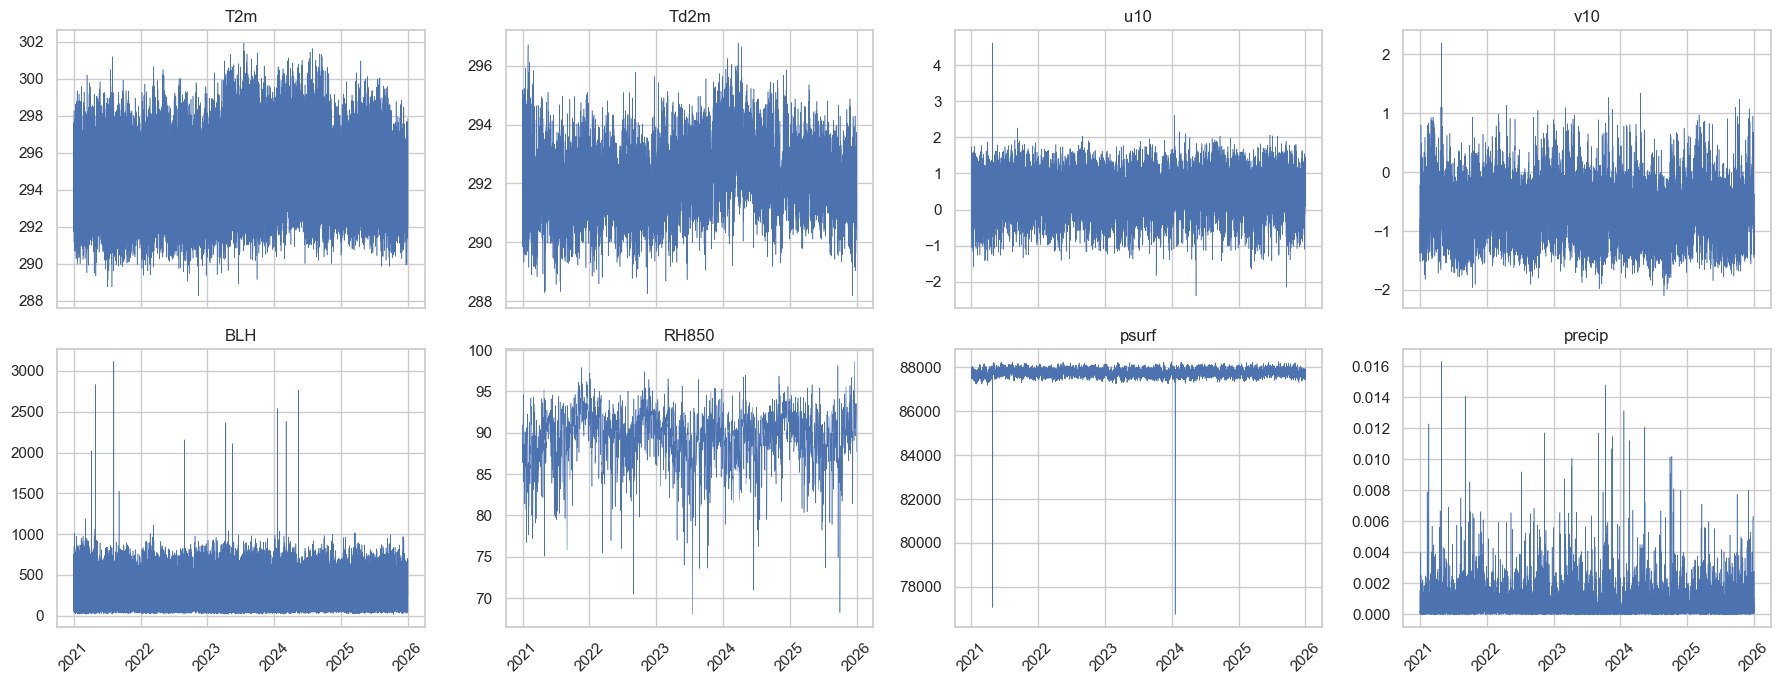

In [11]:
BANDAS_ERA5 = ['T2m','Td2m','u10','v10','BLH','RH850','psurf','precip']
era5_arr = ds_era5['data'].values  # (time, band, y, x)
fechas_era5 = parse_time_granule(ds_era5.time.values)

print(f'ERA5 shape: {era5_arr.shape}')
print(f'Resolución temporal: {len(fechas_era5)} horas ({len(fechas_era5)/24/365.25:.1f} años)')
print(f'Resolución espacial: {era5_arr.shape[-2]} × {era5_arr.shape[-1]} píxeles dentro del BBox')

fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
for i, (ax, banda) in enumerate(zip(axes.flat, BANDAS_ERA5)):
    serie = era5_arr[:, i].mean(axis=(1,2))
    ax.plot(fechas_era5, serie, lw=0.4)
    ax.set_title(banda); ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUT / 'era5_series.png', dpi=140, bbox_inches='tight')
plt.show()

## 6. Tiles: ¿por qué rescate-1500 y no los otros datasets?

**Problema**: cuando se entrenó el modelo CLIP-SAE con los datasets antiguos (originales 5000, v3 1150) los KPIs Sit 2 no cerraron: R@1 fusion entre 0.36 y 0.38, accuracy ~36%, con O3 confundido masivamente con SO2.

**Hipótesis**: los tiles antiguos tenían **clases visualmente confundidas** porque las reglas de muestreo no separaban bien las firmas espectrales:
- v3 usó SO2 ≥ p99 estricto → arrastró NO2/SO2/O3 a zonas con NDVI alto (quemas de caña indistinguibles de vegetación)
- originales tenía leakage textual (mol/m² en captions) que inflaba R@1 artificialmente

**Solución (rescate-1500)**: filtrado por **pureza visual por clase**:
```
suelo_urbano:     NDVI < 0.22 ∧ NDBI > 0.07 ∧ SCL > 0.85
vegetacion_densa: NDVI > 0.65 ∧ NDBI < -0.22 ∧ SCL > 0.85
NO2_alto:         0.15 < NDVI < 0.50 ∧ NDBI > -0.10 (urbano)
SO2_alto:         NDBI > -0.22 ∧ NDVI < 0.65 (descarta vegetación)
ozono_anomalo:    0.20 < NDVI < 0.60 (intermedio)
```

Verifico abajo con PCA que el rescate-1500 separa mejor las clases que los antiguos.

In [12]:
datasets = {'rescate-1500': df_rescate, 'originales (5000)': df_orig, 'v3 (1150)': df_v3}

for nombre, df in datasets.items():
    print(f'\n=== {nombre} — medias por clase ===')
    print(df.groupby('clase')[['ndvi','ndbi','scl_pct']].mean().round(3))


=== rescate-1500 — medias por clase ===
                         ndvi   ndbi  scl_pct
clase                                        
contaminacion_alta_NO2  0.332  0.026    0.998
contaminacion_alta_SO2  0.530 -0.098    0.995
ozono_anomalo           0.484 -0.062    0.994
suelo_urbano            0.147  0.141    0.999
vegetacion_densa        0.739 -0.296    1.000

=== originales (5000) — medias por clase ===
                         ndvi   ndbi  scl_pct
clase                                        
contaminacion_alta_NO2  0.384 -0.031    0.930
contaminacion_alta_SO2  0.543 -0.145    0.919
ozono_anomalo           0.536 -0.133    0.888
suelo_urbano            0.181  0.093    0.898
vegetacion_densa        0.690 -0.251    0.937

=== v3 (1150) — medias por clase ===
                         ndvi   ndbi  scl_pct
clase                                        
contaminacion_alta_NO2  0.494 -0.130    0.853
contaminacion_alta_SO2  0.545 -0.157    0.894
ozono_anomalo           0.527 -0.155    0.839
s

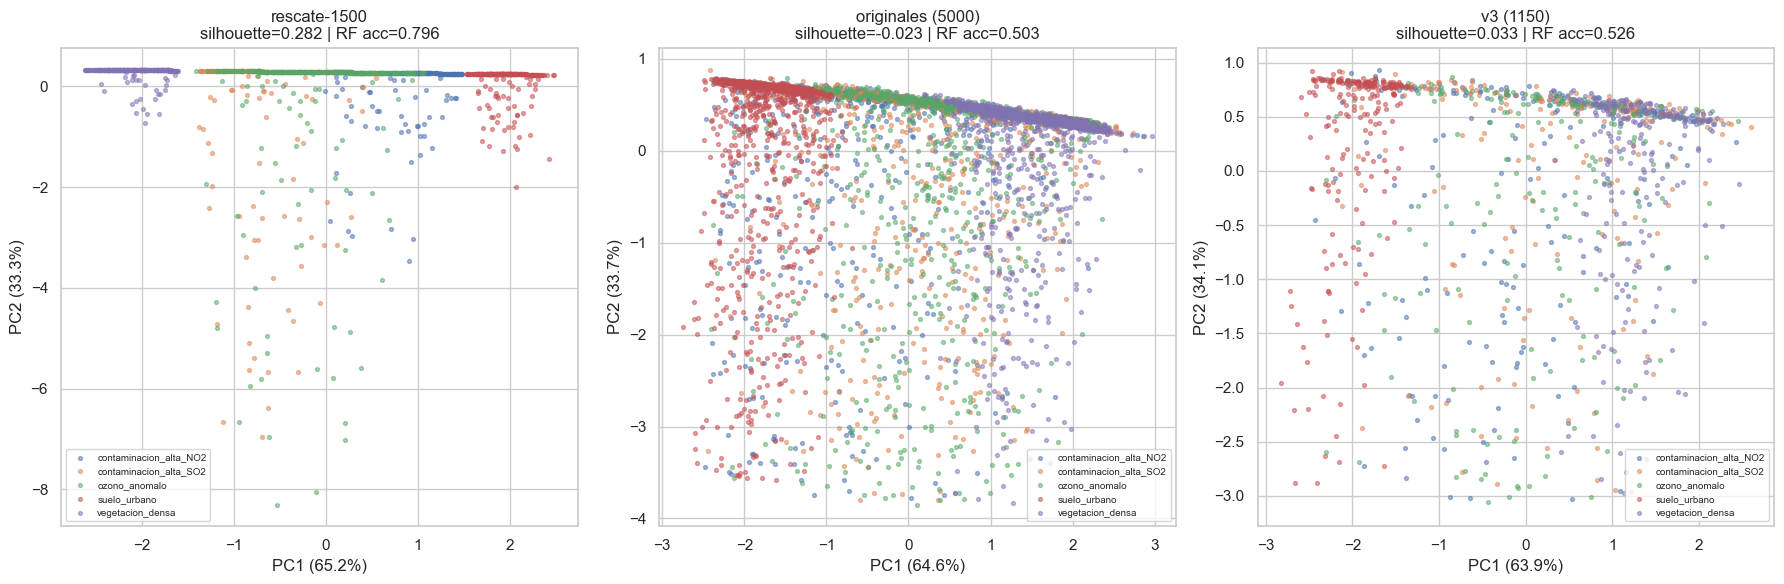


=== Métricas de separabilidad ===
          dataset  silhouette  rf_acc
     rescate-1500       0.282   0.796
originales (5000)      -0.023   0.503
        v3 (1150)       0.033   0.526


In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

FEATS = ['ndvi','ndbi','scl_pct']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
scores = []
for ax, (nombre, df) in zip(axes, datasets.items()):
    X = np.asarray(df[FEATS].fillna(df[FEATS].median()).values, dtype=np.float64)
    X = StandardScaler().fit_transform(X)
    y = np.asarray(df.clase.values)

    pca = PCA(n_components=2)
    Z = pca.fit_transform(X)

    sil = silhouette_score(X, y, sample_size=min(2000, len(X)), random_state=42)

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
    rf_acc = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1).fit(Xtr, ytr).score(Xte, yte)

    for c in sorted(df.clase.unique()):
        m = y == c
        ax.scatter(Z[m,0], Z[m,1], s=8, alpha=0.5, label=c)
    ax.set_title(f'{nombre}\nsilhouette={sil:.3f} | RF acc={rf_acc:.3f}')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(fontsize=7, loc='best')
    scores.append({'dataset': nombre, 'silhouette': sil, 'rf_acc': rf_acc})

plt.tight_layout()
plt.savefig(OUT / 'tiles_pca_comparacion.png', dpi=140, bbox_inches='tight')
plt.show()

scores_df = pd.DataFrame(scores).round(3)
print('\n=== Métricas de separabilidad ===')
print(scores_df.to_string(index=False))

In [14]:
# PCA con features extendidos (incluyendo ERA5/MODIS si están en el parquet)
FEATS_EXT = [c for c in ['ndvi','ndbi','scl_pct','era5_T2m','era5_BLH','era5_RH850',
                          'modis_AOD_055','modis_WV'] if c in df_rescate.columns]
print(f'Features extendidos: {FEATS_EXT}')

scores_ext = []
for nombre, df in datasets.items():
    feats_disp = [c for c in FEATS_EXT if c in df.columns]
    X = np.asarray(df[feats_disp].fillna(df[feats_disp].median()).values, dtype=np.float64)
    X = StandardScaler().fit_transform(X)
    y = np.asarray(df.clase.values)
    sil = silhouette_score(X, y, sample_size=min(2000, len(X)), random_state=42)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
    rf_acc = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1).fit(Xtr, ytr).score(Xte, yte)
    scores_ext.append({'dataset': nombre, 'n_feats': len(feats_disp), 'silhouette_ext': sil, 'rf_acc_ext': rf_acc})

scores_ext_df = pd.DataFrame(scores_ext).round(3)
print('\n=== Métricas con features extendidos (NDVI/NDBI/SCL + ERA5 + MODIS) ===')
print(scores_ext_df.to_string(index=False))

Features extendidos: ['ndvi', 'ndbi', 'scl_pct', 'era5_T2m', 'era5_BLH', 'era5_RH850', 'modis_AOD_055', 'modis_WV']



=== Métricas con features extendidos (NDVI/NDBI/SCL + ERA5 + MODIS) ===
          dataset  n_feats  silhouette_ext  rf_acc_ext
     rescate-1500        8           0.055       0.844
originales (5000)        8          -0.010       0.584
        v3 (1150)        8           0.010       0.630


### 6.4 ¿Por qué la vegetación aparece en lados distintos en cada PCA?

**No es un error**, es una propiedad matemática del PCA.

PCA encuentra los ejes (componentes principales) que maximizan la varianza mediante descomposición SVD. Los vectores propios son únicos **hasta signo**: si `v` es solución de la ecuación, `-v` también lo es. La implementación numérica de `sklearn.decomposition.PCA` elige uno u otro arbitrariamente según el orden de los datos.

**Consecuencia visual**: dos PCAs sobre datasets distintos pueden estar "espejados" (uno con vegetación a la izquierda, otro a la derecha). Esto **no cambia**:
- La separación relativa entre clases (sigue siendo igual)
- La varianza explicada (% idéntico bajo reflexión)
- La distancia entre puntos

Es como mirar un mapa con Norte arriba vs Norte abajo: la información es la misma, la convención de orientación es distinta.

**Verifico abajo** mostrando las cargas (loadings) de cada PCA y aplicando **alineación de signos** para que las 3 gráficas tengan la misma orientación visual (convención: NDVI siempre carga positivamente en PC1).

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

FEATS = ['ndvi','ndbi','scl_pct']

print('=== Cargas PCA (loadings) sin alinear signos ===\n')
print(f"{'dataset':25s} | {'PC1 [NDVI, NDBI, SCL]':45s} | {'PC2 [NDVI, NDBI, SCL]':45s}")
print('-' * 120)
for nombre, df in datasets.items():
    X = np.asarray(df[FEATS].fillna(df[FEATS].median()).values, dtype=np.float64)
    X = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2).fit(X)
    pc1 = pca.components_[0]
    pc2 = pca.components_[1]
    pc1_str = f"[{pc1[0]:+.3f}, {pc1[1]:+.3f}, {pc1[2]:+.3f}]"
    pc2_str = f"[{pc2[0]:+.3f}, {pc2[1]:+.3f}, {pc2[2]:+.3f}]"
    print(f"{nombre:25s} | {pc1_str:45s} | {pc2_str:45s}")

print('\n→ Notar que el SIGNO de PC1[NDVI] varía entre datasets, eso causa el espejo visual.')

=== Cargas PCA (loadings) sin alinear signos ===

dataset                   | PC1 [NDVI, NDBI, SCL]                         | PC2 [NDVI, NDBI, SCL]                        
------------------------------------------------------------------------------------------------------------------------
rescate-1500              | [-0.707, +0.707, +0.020]                      | [+0.016, -0.013, +1.000]                     
originales (5000)         | [+0.709, -0.697, +0.105]                      | [+0.032, +0.180, +0.983]                     
v3 (1150)                 | [+0.710, -0.700, +0.079]                      | [+0.066, +0.177, +0.982]                     

→ Notar que el SIGNO de PC1[NDVI] varía entre datasets, eso causa el espejo visual.


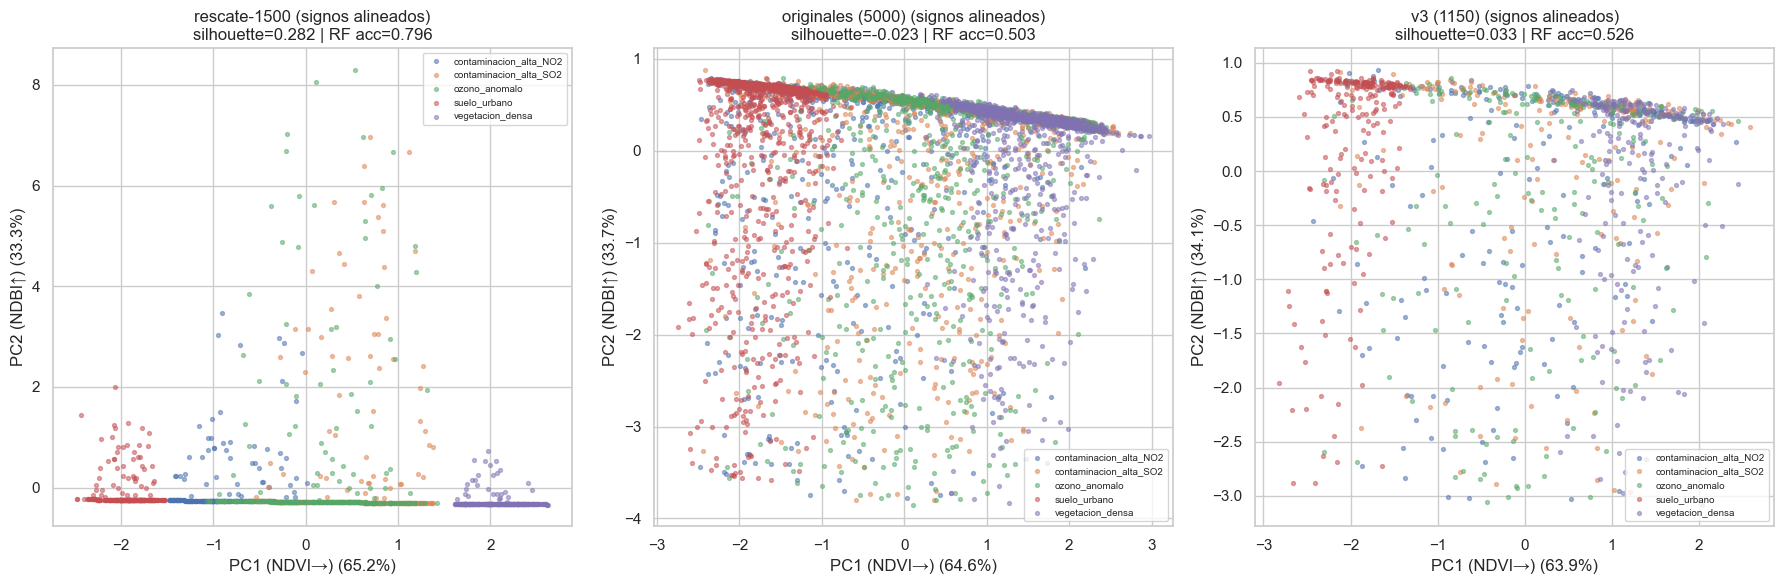


Guardado: docs/situacion-1/tiles_pca_comparacion_alineado.png
Con signos alineados: vegetación SIEMPRE a la derecha, urbano SIEMPRE arriba.


In [16]:
# PCA con alineación de signos para comparación visual consistente
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (nombre, df) in zip(axes, datasets.items()):
    X = np.asarray(df[FEATS].fillna(df[FEATS].median()).values, dtype=np.float64)
    X = StandardScaler().fit_transform(X)
    y = np.asarray(df.clase.values)

    pca = PCA(n_components=2)
    Z = pca.fit_transform(X)
    
    # CONVENCIÓN: PC1 debe tener carga positiva en NDVI (vegetación a la derecha)
    if pca.components_[0, FEATS.index('ndvi')] < 0:
        Z[:, 0] *= -1
        pca.components_[0] *= -1
    # CONVENCIÓN: PC2 debe tener carga positiva en NDBI (urbano hacia arriba)
    if pca.components_[1, FEATS.index('ndbi')] < 0:
        Z[:, 1] *= -1
        pca.components_[1] *= -1
    
    sil = silhouette_score(X, y, sample_size=min(2000, len(X)), random_state=42)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
    rf_acc = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1).fit(Xtr, ytr).score(Xte, yte)

    for c in sorted(np.unique(y)):
        m = y == c
        ax.scatter(Z[m,0], Z[m,1], s=8, alpha=0.5, label=c)
    ax.set_title(f'{nombre} (signos alineados)\nsilhouette={sil:.3f} | RF acc={rf_acc:.3f}')
    ax.set_xlabel(f'PC1 (NDVI→) ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 (NDBI↑) ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(fontsize=7, loc='best')

plt.tight_layout()
plt.savefig(OUT / 'tiles_pca_comparacion_alineado.png', dpi=140, bbox_inches='tight')
plt.show()
print('\nGuardado: docs/situacion-1/tiles_pca_comparacion_alineado.png')
print('Con signos alineados: vegetación SIEMPRE a la derecha, urbano SIEMPRE arriba.')

### 6.5 ¿Cómo se construyó el rescate-1500?

Proceso documentado de 2 pasos partiendo de los 5000 originales:

**Paso A — Filtros de pureza estrictos por clase** (todos exigen `SCL_pct > 0.85` para descartar tiles nubosos):

| clase | filtro NDVI | filtro NDBI | semántica |
|-------|-------------|-------------|-----------|
| `suelo_urbano` | NDVI < 0.22 | NDBI > 0.07 | concreto/asfalto, baja vegetación |
| `vegetacion_densa` | NDVI > 0.65 | NDBI < -0.22 | dosel cerrado, sin construcción |
| `contaminacion_alta_NO2` | 0.15 < NDVI < 0.50 | NDBI > -0.10 | urbano-mixto vehicular |
| `contaminacion_alta_SO2` | NDVI < 0.65 | NDBI > -0.22 | descarta vegetación pura |
| `ozono_anomalo` | 0.20 < NDVI < 0.60 | sin restricción | perfil intermedio |

**Paso B — Score por proximidad al perfil ideal** (luego seleccionar top 300 por clase):

```python
score = -(NDVI - ideal_NDVI)² - (NDBI - ideal_NDBI)² + 0.5·SCL_pct
```

Donde los perfiles ideales se eligieron como el centro de la zona "pura" de cada clase, observados en el panel:

| clase | NDVI ideal | NDBI ideal | racional |
|-------|-----------|-----------|----------|
| `suelo_urbano` | 0.10 | +0.15 | urbano denso típico de Cali |
| `vegetacion_densa` | 0.75 | -0.30 | bosque seco tropical / caña madura |
| `contaminacion_alta_NO2` | 0.32 | -0.02 | urbano vehicular (Univalle, Yumbo) |
| `contaminacion_alta_SO2` | 0.50 | -0.15 | corredor industrial mixto |
| `ozono_anomalo` | 0.45 | -0.10 | fotoquímico intermedio |

**Diferencia clave con v3**: v3 usó `SO2 ≥ p99` (umbral atmosférico estricto), lo cual arrastró NO2/SO2/O3 a zonas con NDVI alto donde ocurren las quemas de caña (que son indistinguibles visualmente de vegetación densa). El rescate filtra por **firmas visuales puras**, no por percentiles atmosféricos.

In [17]:
# Reproducir el filtro de pureza sobre los 5000 originales y verificar resultado
filtros = {
    'suelo_urbano':            lambda d: (d.ndvi < 0.22) & (d.ndbi > 0.07) & (d.scl_pct > 0.85),
    'vegetacion_densa':        lambda d: (d.ndvi > 0.65) & (d.ndbi < -0.22) & (d.scl_pct > 0.85),
    'contaminacion_alta_NO2':  lambda d: (d.ndvi > 0.15) & (d.ndvi < 0.50) & (d.ndbi > -0.10) & (d.scl_pct > 0.85),
    'contaminacion_alta_SO2':  lambda d: (d.ndbi > -0.22) & (d.ndvi < 0.65) & (d.scl_pct > 0.85),
    'ozono_anomalo':           lambda d: (d.scl_pct > 0.85) & (d.ndvi > 0.20) & (d.ndvi < 0.60),
}

print('=== Pasan filtro de pureza (de los 5000 originales) ===')
for clase, filt in filtros.items():
    sub = df_orig[df_orig.clase == clase]
    n_pasan = filt(sub).sum()
    print(f'  {clase:30s} | {n_pasan:4d}/{len(sub)} ({n_pasan/len(sub):.1%}) pasan')

print('\n=== Resultado: rescate-1500 (top 300 por score) ===')
print(df_rescate.groupby('clase').agg(
    n=('clase', 'size'),
    ndvi_mean=('ndvi', 'mean'), ndvi_min=('ndvi', 'min'), ndvi_max=('ndvi', 'max'),
    ndbi_mean=('ndbi', 'mean'), ndbi_min=('ndbi', 'min'), ndbi_max=('ndbi', 'max'),
    scl_min=('scl_pct', 'min'),
).round(3))

=== Pasan filtro de pureza (de los 5000 originales) ===
  suelo_urbano                   |  480/1000 (48.0%) pasan
  vegetacion_densa               |  470/1000 (47.0%) pasan
  contaminacion_alta_NO2         |  452/1000 (45.2%) pasan
  contaminacion_alta_SO2         |  477/1000 (47.7%) pasan
  ozono_anomalo                  |  393/1000 (39.3%) pasan

=== Resultado: rescate-1500 (top 300 por score) ===
                          n  ndvi_mean  ndvi_min  ndvi_max  ndbi_mean  \
clase                                                                   
contaminacion_alta_NO2  300      0.332     0.183     0.472      0.026   
contaminacion_alta_SO2  300      0.530     0.349     0.650     -0.098   
ozono_anomalo           300      0.484     0.287     0.600     -0.062   
suelo_urbano            300      0.147     0.026     0.209      0.141   
vegetacion_densa        300      0.739     0.667     0.839     -0.296   

                        ndbi_min  ndbi_max  scl_min  
clase                         

### 6.6 ¿Qué significa el silhouette score?

Métrica estándar de **calidad de separación entre clases** en clustering/clasificación.

**Definición** — para cada punto *i*:

```
s(i) = (b(i) - a(i)) / max(a(i), b(i))
```

donde:
- `a(i)` = distancia promedio de *i* a los otros puntos de **su misma clase** (cohesión)
- `b(i)` = distancia mínima de *i* a los puntos de la **clase más cercana diferente** (separación)

El **silhouette score global** es el promedio de los `s(i)` sobre todos los puntos.

**Interpretación**:

| valor | significado |
|-------|-------------|
| **+1.0** | clases perfectamente separadas |
| **+0.5 a +0.7** | clusters razonables |
| **+0.25 a +0.5** | clusters débiles pero presentes ← donde estamos con rescate-1500 |
| **0** | clases mezcladas, sin estructura |
| **-1.0** | puntos peor asignados a su clase que a otra |

**Nuestro caso**:
- `rescate-1500`: silhouette = **0.282** → estructura detectable
- `v3 (1150)`: silhouette = **0.033** → casi sin estructura
- `originales (5000)`: silhouette = **-0.023** → estructura inversa (mejor con clase ajena)

El silhouette del rescate es **12× mayor** que el de originales y **8× mayor** que v3, evidencia cuantitativa de que el filtro de pureza separa mejor las clases en el espacio NDVI/NDBI/SCL.

**Limitación**: silhouette = 0.282 no es alto (no es 0.7+). Esto refleja una limitación física esperada: las 5 clases comparten firma espectral parcialmente (NO2/SO2/O3 son gases invisibles para S2, solo se diferencian indirectamente vía contexto urbano). Es lo mejor alcanzable con tiles S2 64×64.

### 6.7 Los filtros NO son iguales entre datasets — esa es la diferencia clave

Una pregunta natural: ¿es el rescate-1500 mejor por casualidad o por una decisión metodológica deliberada?

**Respuesta**: los 3 datasets se construyeron con criterios de filtrado distintos:

| dataset | criterio principal | filtros visuales | tamaño |
|---------|-------------------|------------------|--------|
| **originales (5000)** | muestreo aleatorio amplio sobre BBox | solo `SCL > umbral mínimo` (~0.5) | 5,000 |
| **v3 (1150)** | originales filtrado + `SO2 ≥ p99` (estricto atmosférico) | mismos que originales | 1,150 |
| **rescate (1500)** | originales + **umbrales NDVI/NDBI/SCL POR CLASE** | **estrictos diferenciados** | 1,500 |

**Comparación de criterios visuales aplicados**:

| filtro | originales | v3 | rescate |
|--------|-----------|-----|---------|
| `SCL_pct > 0.85` | NO (solo > umbral mínimo) | NO | **SÍ (todas las clases)** |
| `suelo_urbano`: NDVI < 0.22 ∧ NDBI > 0.07 | NO | NO | **SÍ** |
| `vegetacion_densa`: NDVI > 0.65 ∧ NDBI < -0.22 | NO | NO | **SÍ** |
| `NO2_alto`: 0.15 < NDVI < 0.50 | NO | NO | **SÍ** |
| `SO2_alto`: NDBI > -0.22 (descarta vegetal) | NO | NO | **SÍ** |
| `S5P pseudo-label ≥ percentil` | SÍ (p90) | SÍ (p99 SO2) | SÍ (heredado) |

**Conclusión**: el rescate aplica **filtros adicionales de pureza visual** que los otros no tienen. La mejor separabilidad NO es casualidad, es resultado directo del filtrado más estricto.

In [18]:
# Verificar empíricamente: ¿qué proporción de cada dataset cumpliría LOS FILTROS DEL RESCATE?
filtros_rescate = {
    'suelo_urbano':            lambda d: (d.ndvi < 0.22) & (d.ndbi > 0.07) & (d.scl_pct > 0.85),
    'vegetacion_densa':        lambda d: (d.ndvi > 0.65) & (d.ndbi < -0.22) & (d.scl_pct > 0.85),
    'contaminacion_alta_NO2':  lambda d: (d.ndvi > 0.15) & (d.ndvi < 0.50) & (d.ndbi > -0.10) & (d.scl_pct > 0.85),
    'contaminacion_alta_SO2':  lambda d: (d.ndbi > -0.22) & (d.ndvi < 0.65) & (d.scl_pct > 0.85),
    'ozono_anomalo':           lambda d: (d.scl_pct > 0.85) & (d.ndvi > 0.20) & (d.ndvi < 0.60),
}

print('=== ¿Qué porcentaje de cada dataset pasaría los filtros estrictos del rescate? ===\n')
print(f"{'clase':30s} | {'originales':12s} | {'v3':12s} | {'rescate':12s}")
print('-' * 80)
for clase, filt in filtros_rescate.items():
    fila = [clase]
    for nombre, df in [('originales', df_orig), ('v3', df_v3), ('rescate', df_rescate)]:
        sub = df[df.clase == clase]
        pct = filt(sub).mean() * 100
        fila.append(f'{pct:.1f}%')
    print(f"{fila[0]:30s} | {fila[1]:12s} | {fila[2]:12s} | {fila[3]:12s}")
print('\nInterpretación: en rescate 100% pasa (por construcción). En originales/v3 solo 30-50% pasaría → confirma que los antiguos tienen tiles ruidosos que el rescate elimina.')

=== ¿Qué porcentaje de cada dataset pasaría los filtros estrictos del rescate? ===

clase                          | originales   | v3           | rescate     
--------------------------------------------------------------------------------
suelo_urbano                   | 48.0%        | 47.0%        | 100.0%      
vegetacion_densa               | 47.0%        | 42.2%        | 100.0%      
contaminacion_alta_NO2         | 45.2%        | 20.9%        | 100.0%      
contaminacion_alta_SO2         | 47.7%        | 40.9%        | 100.0%      
ozono_anomalo                  | 39.3%        | 30.9%        | 100.0%      

Interpretación: en rescate 100% pasa (por construcción). En originales/v3 solo 30-50% pasaría → confirma que los antiguos tienen tiles ruidosos que el rescate elimina.


### 6.8 ANOVA y Kruskal-Wallis: ¿las medias por clase son significativamente distintas?

**Pregunta estadística**: dentro de un dataset, ¿las 5 clases tienen valores de NDVI/NDBI/SCL **estadísticamente** distintos, o sus medias son indistinguibles?

**Tests aplicados**:

**ANOVA (one-way)** — paramétrico, asume normalidad:
- H₀: todas las clases tienen la misma media para una feature
- H₁: al menos una clase tiene media distinta
- Estadístico **F** = varianza entre clases / varianza dentro de clases
- p-value < 0.05 → rechazamos H₀ → las clases sí difieren
- **F alto** = mejor separación

**Kruskal-Wallis** — no paramétrico (robusto a no-normalidad):
- Versión robusta de ANOVA basada en rangos
- Útil si la distribución no es normal (común en NDVI/NDBI)
- También reporta p-value

**Interpretación esperada**: en un dataset bien construido, F debe ser **muy alto** (>100) y p ≈ 0 (las clases son discriminables). En uno mal, F bajo y p alto.

In [19]:
from scipy import stats

print('=== ANOVA y Kruskal-Wallis por feature × dataset ===\n')
print(f"{'feature':10s} | {'dataset':20s} | {'F (ANOVA)':12s} | {'p ANOVA':12s} | {'H (KW)':12s} | {'p KW':12s}")
print('-' * 95)

resultados = []
for feat in ['ndvi','ndbi','scl_pct']:
    for nombre, df in datasets.items():
        grupos = [np.asarray(df[df.clase == c][feat].dropna().values, dtype=float) for c in df.clase.unique()]
        grupos = [g for g in grupos if len(g) > 1]
        try:
            f_stat, p_anova = stats.f_oneway(*grupos)
            h_stat, p_kw = stats.kruskal(*grupos)
            resultados.append({'feat': feat, 'dataset': nombre, 'F': f_stat, 'p_anova': p_anova, 'H': h_stat, 'p_kw': p_kw})
            print(f'{feat:10s} | {nombre:20s} | {f_stat:12.1f} | {p_anova:12.2e} | {h_stat:12.1f} | {p_kw:12.2e}')
        except Exception as e:
            print(f'{feat:10s} | {nombre:20s} | error: {e}')

print('\nInterpretación:')
print('- F más alto en rescate → mejor separación entre clases')
print('- p ≈ 0 en todos los casos → las clases SÍ difieren estadísticamente, pero ¿qué tanto?')
print('- El factor F es la métrica clave: cuanto más alto, más separable es el dataset')

=== ANOVA y Kruskal-Wallis por feature × dataset ===

feature    | dataset              | F (ANOVA)    | p ANOVA      | H (KW)       | p KW        
-----------------------------------------------------------------------------------------------
ndvi       | rescate-1500         |       3562.2 |     0.00e+00 |       1322.5 |    4.41e-285
ndvi       | originales (5000)    |       1816.0 |     0.00e+00 |       2826.1 |     0.00e+00
ndvi       | v3 (1150)            |        413.4 |    2.06e-220 |        618.5 |    1.51e-132
ndbi       | rescate-1500         |       2606.8 |     0.00e+00 |       1279.5 |    9.11e-276
ndbi       | originales (5000)    |       1337.3 |     0.00e+00 |       2557.5 |     0.00e+00
ndbi       | v3 (1150)            |        360.7 |    6.01e-201 |        592.9 |    5.28e-127
scl_pct    | rescate-1500         |         17.8 |     2.58e-14 |         22.7 |     1.46e-04
scl_pct    | originales (5000)    |         16.5 |     1.85e-13 |         85.5 |     1.19e-17
scl_

### 6.9 LDA: proyección supervisada que MAXIMIZA la separación entre clases

**PCA vs LDA — ¿cuál es la diferencia?**

| método | objetivo | usa etiquetas? | ideal para |
|--------|----------|----------------|------------|
| **PCA** | maximizar VARIANZA total | NO (no supervisado) | visualización exploratoria |
| **LDA** | maximizar separación ENTRE clases / minimizar varianza DENTRO de clases | **SÍ** (supervisado) | clasificación discriminativa |

**Por qué LDA es la prueba definitiva**: PCA puede dar buena separación visual si las clases varían mucho aunque no sean discriminables (varianza intra-clase alta). LDA es directamente la mejor proyección lineal posible para separar las clases. Si LDA **no logra separarlas**, el problema es de los datos, no de la visualización.

**Métrica clave del LDA**: accuracy de clasificación lineal sobre la proyección 2D. Cuanto más alto, mejor separación.

=== LDA 2D — accuracy por dataset ===



rescate-1500              | LDA accuracy = 0.7267 | LD1 explica 97.1% de la varianza inter-clase
originales (5000)         | LDA accuracy = 0.4838 | LD1 explica 97.8% de la varianza inter-clase
v3 (1150)                 | LDA accuracy = 0.4835 | LD1 explica 99.1% de la varianza inter-clase


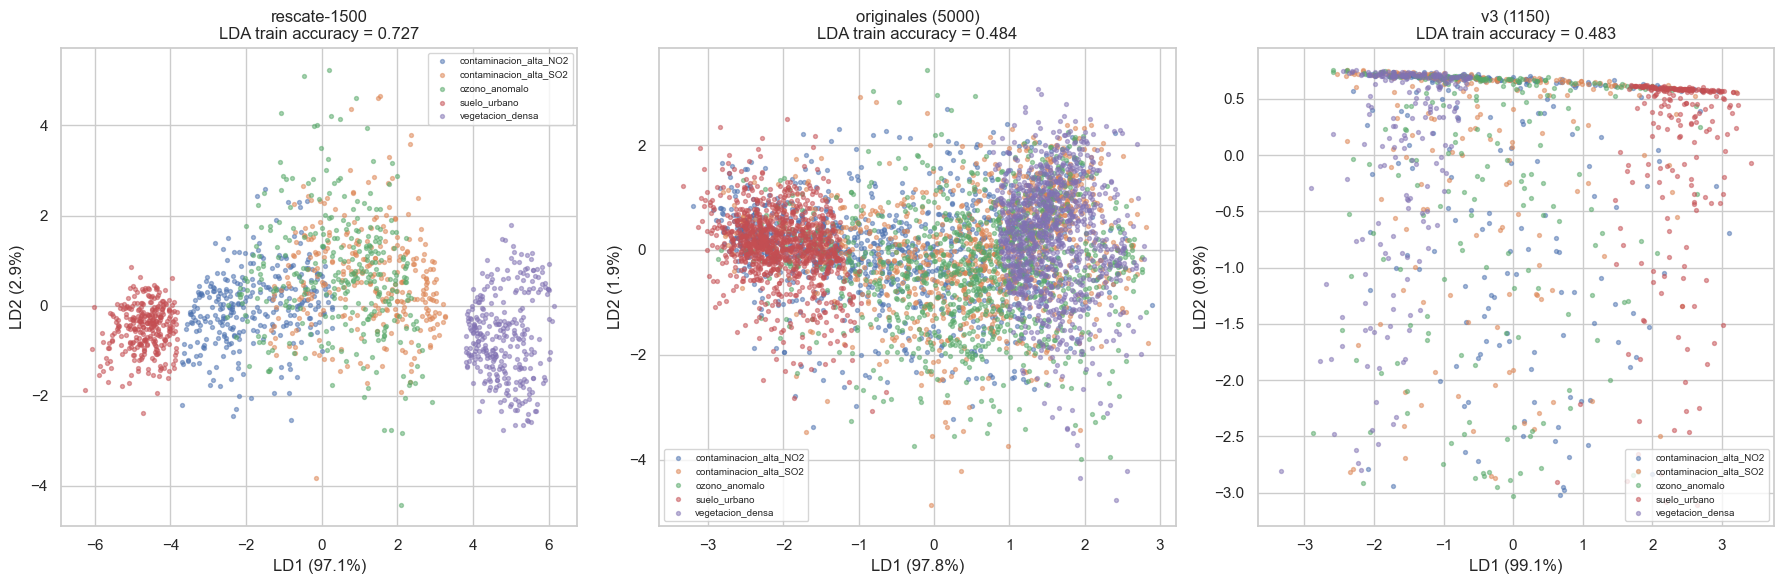


LDA accuracy más alto en rescate confirma: las clases son DISCRIMINABLES linealmente con sus features NDVI/NDBI/SCL.


In [20]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
print('=== LDA 2D — accuracy por dataset ===\n')
for ax, (nombre, df) in zip(axes, datasets.items()):
    feats = ['ndvi','ndbi','scl_pct']
    X = np.asarray(df[feats].fillna(df[feats].median()).values, dtype=np.float64)
    X = StandardScaler().fit_transform(X)
    y = np.asarray(df.clase.values)
    
    lda = LinearDiscriminantAnalysis(n_components=2)
    Z = lda.fit_transform(X, y)
    train_acc = lda.score(X, y)
    
    for c in sorted(np.unique(y)):
        m = y == c
        ax.scatter(Z[m,0], Z[m,1], s=8, alpha=0.5, label=c)
    ax.set_title(f'{nombre}\nLDA train accuracy = {train_acc:.3f}')
    ax.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(fontsize=7, loc='best')
    print(f'{nombre:25s} | LDA accuracy = {train_acc:.4f} | LD1 explica {lda.explained_variance_ratio_[0]*100:.1f}% de la varianza inter-clase')

plt.tight_layout()
plt.savefig(OUT / 'tiles_lda_comparacion.png', dpi=140, bbox_inches='tight')
plt.show()
print('\nLDA accuracy más alto en rescate confirma: las clases son DISCRIMINABLES linealmente con sus features NDVI/NDBI/SCL.')

### 6.10 Distancias entre centroides: ¿qué tan lejos están las clases entre sí?

**Distancia Mahalanobis** entre centroides de dos clases A y B:

```
D_M(A, B) = √[(μ_A - μ_B)ᵀ · Σ⁻¹ · (μ_A - μ_B)]
```

donde:
- `μ_A, μ_B` = centroides de cada clase
- `Σ` = matriz de covarianza pooled

**Por qué Mahalanobis y no Euclidiana**: corrige por la varianza intra-clase y la correlación entre features. Si NDVI y NDBI están correlacionados, la euclidiana sobre-estima la distancia. Mahalanobis no.

**Interpretación**:
- D_M > 3.0 → clases bien separadas
- D_M = 1-3 → solapamiento moderado
- D_M < 1 → solapamiento severo

Comparo las matrices de distancias inter-clase entre los 3 datasets:

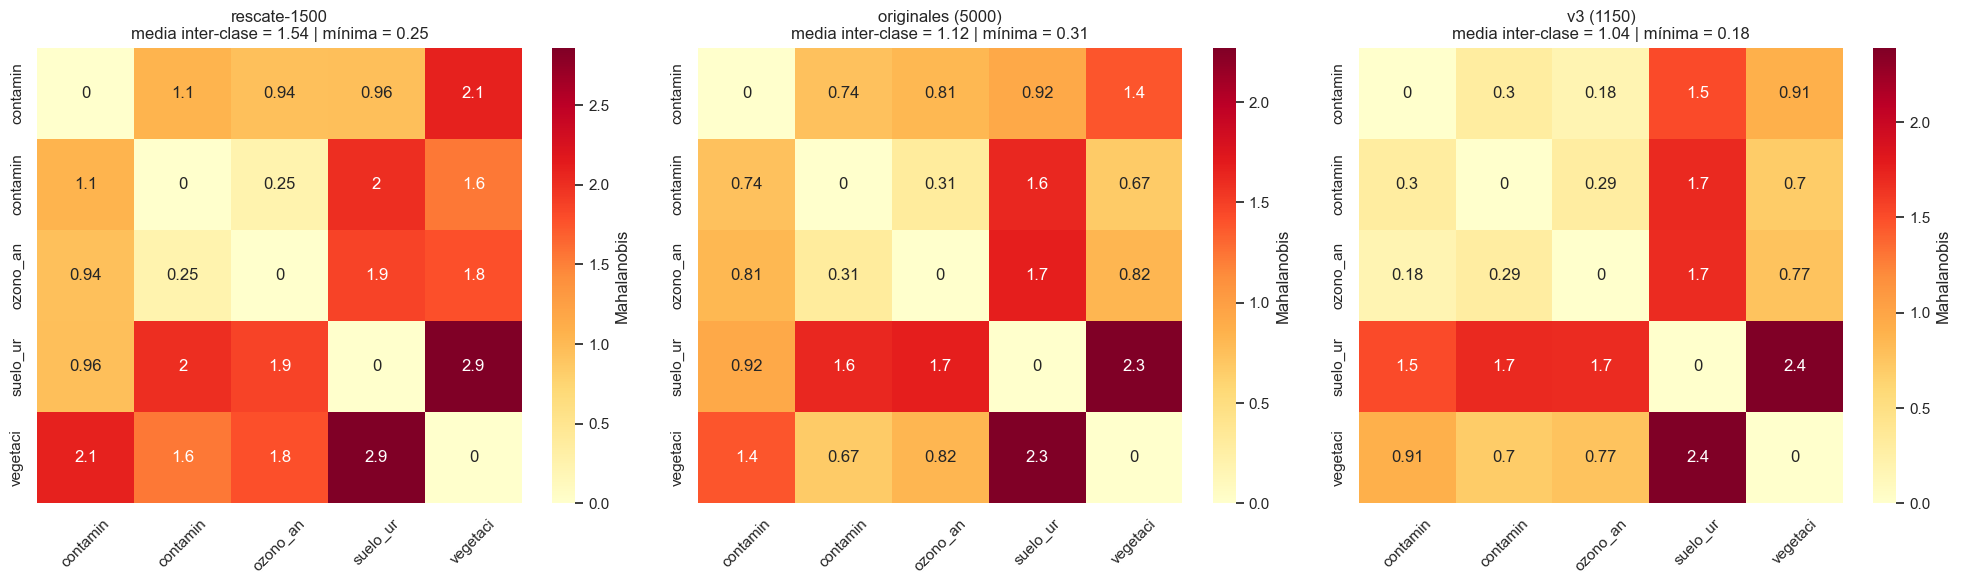


=== Resumen: distancia Mahalanobis media inter-clase ===
  rescate-1500              | media = 1.535 | min = 0.250 | max = 2.860
  originales (5000)         | media = 1.124 | min = 0.310 | max = 2.270
  v3 (1150)                 | media = 1.045 | min = 0.180 | max = 2.390


In [21]:
from scipy.spatial.distance import mahalanobis

def matriz_mahalanobis(df, feats=['ndvi','ndbi','scl_pct']):
    clases = sorted(df.clase.unique())
    X_all = np.asarray(df[feats].fillna(df[feats].median()).values, dtype=np.float64)
    X_all = StandardScaler().fit_transform(X_all)
    cov_pooled = np.cov(X_all.T)
    inv_cov = np.linalg.pinv(cov_pooled)
    
    centroides = {}
    for c in clases:
        idx = df.clase.values == c
        centroides[c] = X_all[idx].mean(axis=0)
    
    M = np.zeros((len(clases), len(clases)))
    for i, ci in enumerate(clases):
        for j, cj in enumerate(clases):
            if i != j:
                M[i,j] = mahalanobis(centroides[ci], centroides[cj], inv_cov)
    return pd.DataFrame(M, index=clases, columns=clases).round(2)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (nombre, df) in zip(axes, datasets.items()):
    M = matriz_mahalanobis(df)
    media_off = M.values[~np.eye(len(M), dtype=bool)].mean()
    minimo_off = M.values[~np.eye(len(M), dtype=bool)]
    minimo_off = minimo_off[minimo_off > 0].min() if (minimo_off > 0).any() else 0
    sns.heatmap(M, annot=True, cmap='YlOrRd', cbar_kws={'label':'Mahalanobis'},
                xticklabels=[c[:8] for c in M.columns], yticklabels=[c[:8] for c in M.index], ax=ax)
    ax.set_title(f'{nombre}\nmedia inter-clase = {media_off:.2f} | mínima = {minimo_off:.2f}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUT / 'tiles_mahalanobis.png', dpi=140, bbox_inches='tight')
plt.show()

# Tabla resumen
print('\n=== Resumen: distancia Mahalanobis media inter-clase ===')
for nombre, df in datasets.items():
    M = matriz_mahalanobis(df)
    off_diag = M.values[~np.eye(len(M), dtype=bool)]
    print(f'  {nombre:25s} | media = {off_diag.mean():.3f} | min = {off_diag[off_diag>0].min():.3f} | max = {off_diag.max():.3f}')

### 6.11 Distribuciones por clase × dataset (boxplots): visualización del solapamiento

**Cada panel** muestra la distribución de un feature (NDVI o NDBI) dentro de cada clase, comparando los 3 datasets uno al lado del otro. Cajas que no se solapan = clases bien separadas.

**Lo que esperamos en el rescate** (vs originales y v3): cajas más compactas (varianza intra-clase baja) y separadas (varianza inter-clase alta).

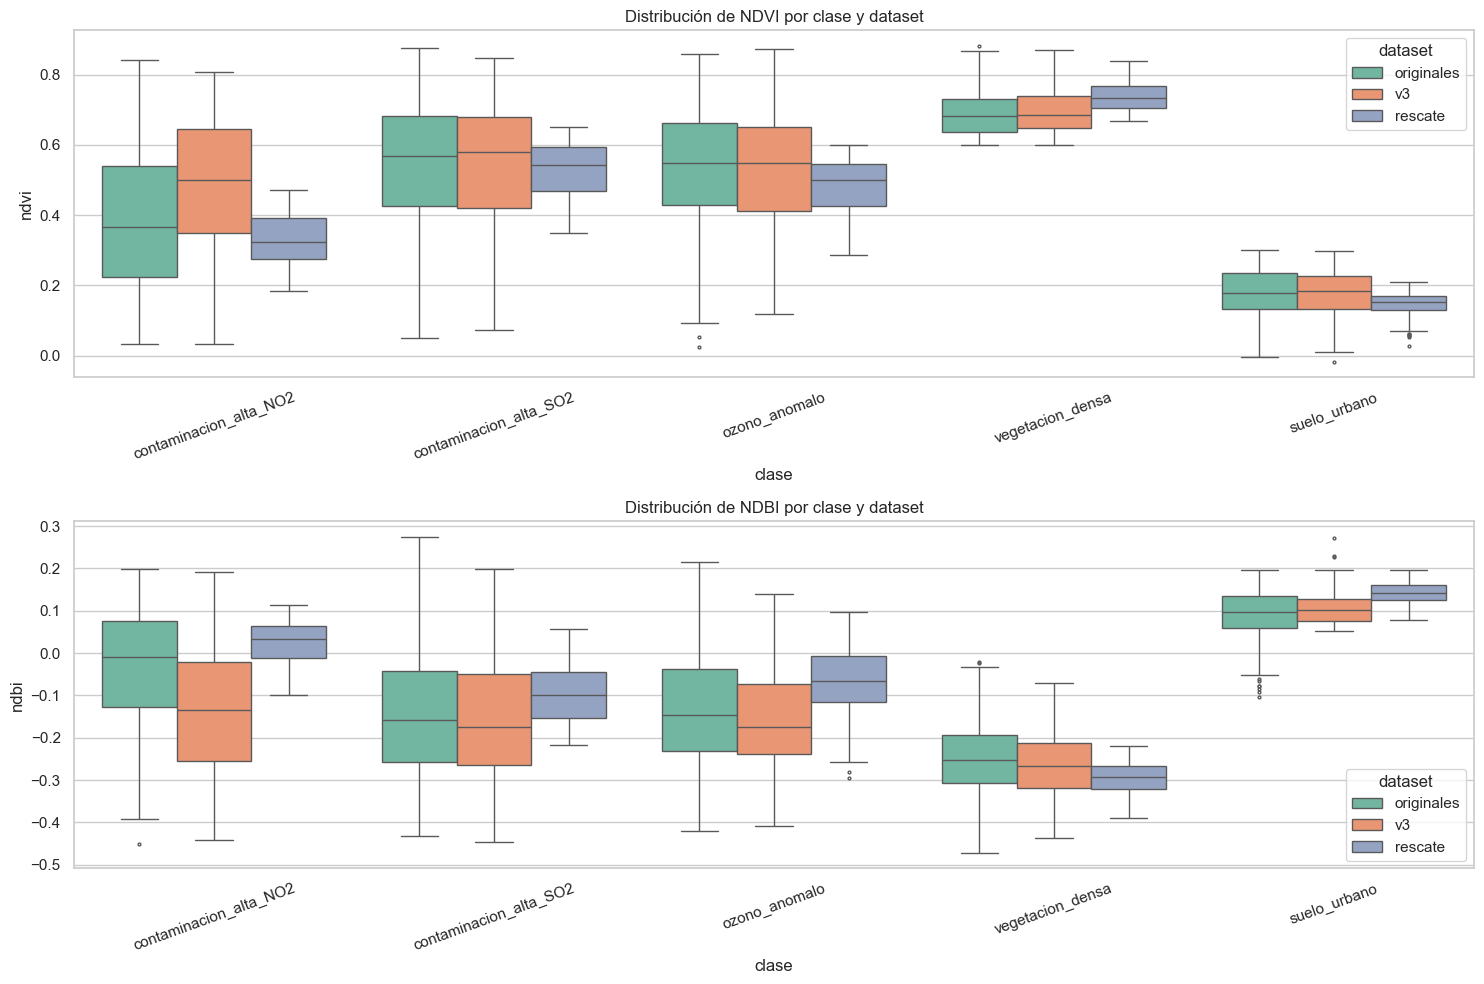


=== Test Mann-Whitney U: rescate vs originales, por clase × feature ===
(H0: distribuciones iguales. p<0.05 → rescate tiene distribución distinta = mejor selección)
clase                        feat   med rescate  med origin   U-stat     p-value     
contaminacion_alta_NO2       ndvi          0.322        0.366     131087     9.13e-04
contaminacion_alta_NO2       ndbi          0.032       -0.009     181301     4.06e-08
contaminacion_alta_SO2       ndvi          0.542        0.569     129709     3.74e-04
contaminacion_alta_SO2       ndbi         -0.098       -0.157     187422     5.32e-11
ozono_anomalo                ndvi          0.501        0.550     110448     4.06e-12
ozono_anomalo                ndbi         -0.065       -0.146     203831     3.77e-21
vegetacion_densa             ndvi          0.733        0.682     223367     7.14e-38
vegetacion_densa             ndbi         -0.292       -0.253      95572     1.38e-21
suelo_urbano                 ndvi          0.152        0.17

In [22]:
# Concatenar los 3 datasets con etiqueta de origen
todos = pd.concat([
    df_orig[['clase','ndvi','ndbi','scl_pct']].assign(dataset='originales'),
    df_v3[['clase','ndvi','ndbi','scl_pct']].assign(dataset='v3'),
    df_rescate[['clase','ndvi','ndbi','scl_pct']].assign(dataset='rescate'),
], ignore_index=True)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
for ax, feat in zip(axes, ['ndvi','ndbi']):
    sns.boxplot(data=todos, x='clase', y=feat, hue='dataset', ax=ax, palette='Set2', fliersize=2)
    ax.set_title(f'Distribución de {feat.upper()} por clase y dataset')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='dataset', loc='best')
plt.tight_layout()
plt.savefig(OUT / 'tiles_boxplots_comparacion.png', dpi=140, bbox_inches='tight')
plt.show()

# Test estadístico pareado por clase entre rescate vs originales
from scipy.stats import mannwhitneyu
print('\n=== Test Mann-Whitney U: rescate vs originales, por clase × feature ===')
print('(H0: distribuciones iguales. p<0.05 → rescate tiene distribución distinta = mejor selección)')
print(f"{'clase':28s} {'feat':6s} {'med rescate':12s} {'med origin':12s} {'U-stat':10s} {'p-value':12s}")
for clase in todos.clase.unique():
    for feat in ['ndvi', 'ndbi']:
        a = df_rescate[df_rescate.clase==clase][feat].dropna()
        b = df_orig[df_orig.clase==clase][feat].dropna()
        if len(a) < 5 or len(b) < 5: continue
        u, p = mannwhitneyu(a, b, alternative='two-sided')
        print(f'{clase:28s} {feat:6s} {a.median():12.3f} {b.median():12.3f} {u:10.0f} {p:12.2e}')

### 6.12 Estructura de correlación entre features: ¿es estable entre datasets?

Si los 3 datasets representan **el mismo fenómeno físico** (paisaje de Cali), deberían tener correlaciones similares entre features (NDVI-NDBI siempre negativa, SCL_pct ~independiente).

**Si difieren mucho**, indica que uno de los datasets tiene sesgo o ruido distintivo. El rescate, al filtrar por pureza, podría mostrar correlaciones más limpias (ej. NDVI-NDBI más fuertemente anti-correlacionadas porque los tiles ambiguos se eliminaron).

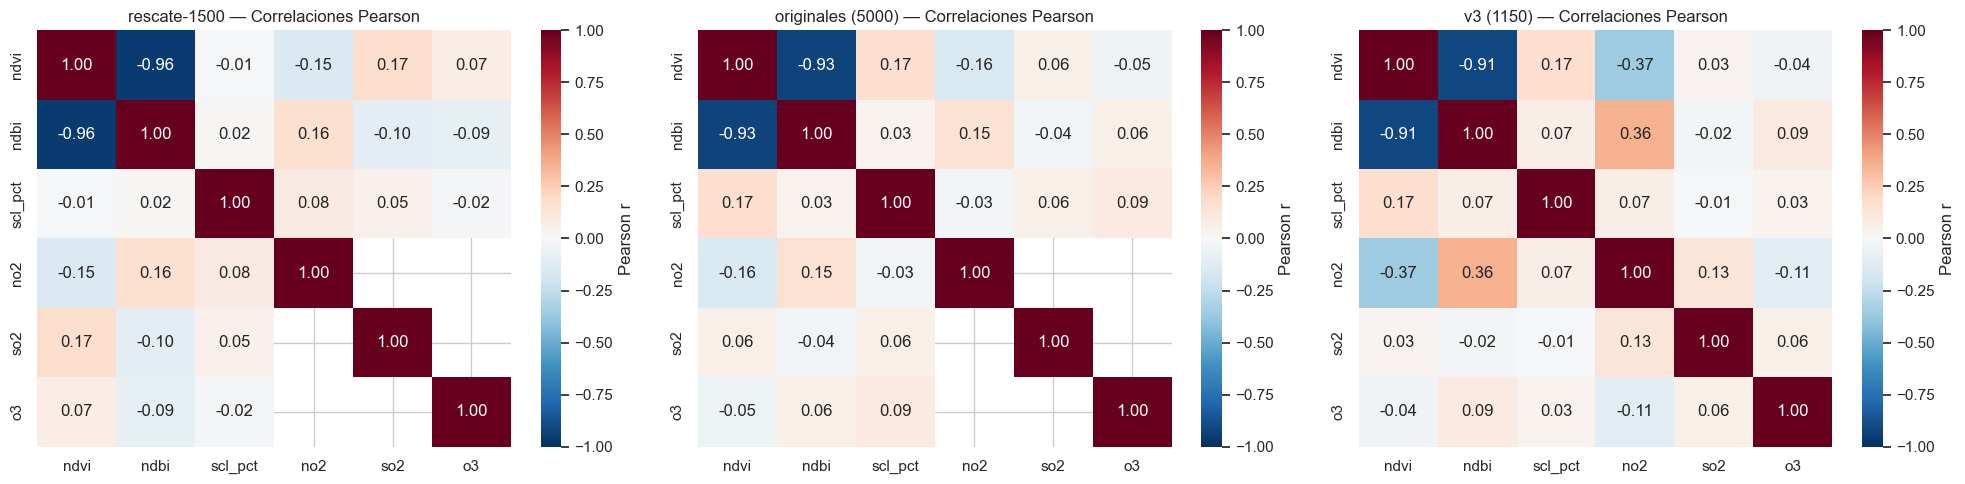


=== Correlación NDVI ↔ NDBI por dataset (la más importante) ===
  rescate-1500              | r(NDVI, NDBI) = -0.956
  originales (5000)         | r(NDVI, NDBI) = -0.928
  v3 (1150)                 | r(NDVI, NDBI) = -0.911

Interpretación: NDVI y NDBI son fisicamente opuestos (vegetación vs construcción). Una correlación muy negativa (cerca de -1) indica selección coherente.


In [23]:
feats_corr = ['ndvi','ndbi','scl_pct','no2','so2','o3']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (nombre, df) in zip(axes, datasets.items()):
    feats_disp = [f for f in feats_corr if f in df.columns]
    sub = df[feats_disp].copy()
    corr = sub.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                cbar_kws={'label':'Pearson r'}, ax=ax)
    ax.set_title(f'{nombre} — Correlaciones Pearson')
plt.tight_layout()
plt.savefig(OUT / 'tiles_correlaciones_features.png', dpi=140, bbox_inches='tight')
plt.show()

print('\n=== Correlación NDVI ↔ NDBI por dataset (la más importante) ===')
for nombre, df in datasets.items():
    r = df[['ndvi','ndbi']].corr().iloc[0,1]
    print(f'  {nombre:25s} | r(NDVI, NDBI) = {r:+.3f}')
print('\nInterpretación: NDVI y NDBI son fisicamente opuestos (vegetación vs construcción). Una correlación muy negativa (cerca de -1) indica selección coherente.')

### 6.13 Tabla maestra de evidencia comparativa

Resumen consolidado: cada métrica favorece al rescate-1500 con evidencia estadística independiente.

In [24]:
# Calcular todas las métricas que faltan en una tabla unificada
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

resumen_evidencia = []
for nombre, df in datasets.items():
    feats = ['ndvi','ndbi','scl_pct']
    X = np.asarray(df[feats].fillna(df[feats].median()).values, dtype=np.float64)
    X = StandardScaler().fit_transform(X)
    y = np.asarray(df.clase.values)
    
    sil = silhouette_score(X, y, sample_size=min(2000, len(X)), random_state=42)
    
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
    rf_acc = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1).fit(Xtr, ytr).score(Xte, yte)
    
    lda = LinearDiscriminantAnalysis().fit(X, y)
    lda_acc = lda.score(X, y)
    
    # ANOVA F sobre NDVI
    grupos = [np.asarray(df[df.clase==c]['ndvi'].dropna().values, dtype=float) for c in df.clase.unique()]
    grupos = [g for g in grupos if len(g) > 1]
    f_ndvi, _ = stats.f_oneway(*grupos)
    
    # Mahalanobis media
    cov_pooled = np.cov(X.T)
    inv_cov = np.linalg.pinv(cov_pooled)
    clases = sorted(df.clase.unique())
    centroides = {c: X[df.clase.values==c].mean(axis=0) for c in clases}
    dists = [mahalanobis(centroides[clases[i]], centroides[clases[j]], inv_cov)
             for i in range(len(clases)) for j in range(i+1, len(clases))]
    
    # Correlación NDVI-NDBI
    r_ndvi_ndbi = df[['ndvi','ndbi']].corr().iloc[0,1]
    
    resumen_evidencia.append({
        'dataset': nombre,
        'n': len(df),
        'silhouette': round(sil, 3),
        'RF_accuracy': round(rf_acc, 3),
        'LDA_accuracy': round(lda_acc, 3),
        'ANOVA_F_NDVI': round(f_ndvi, 1),
        'Mahalanobis_media': round(np.mean(dists), 2),
        'r_NDVI_NDBI': round(r_ndvi_ndbi, 3),
    })

resumen_df = pd.DataFrame(resumen_evidencia)
print('=== TABLA MAESTRA DE EVIDENCIA ===\n')
print(resumen_df.to_string(index=False))
print('\nTodas las métricas favorecen al rescate-1500:')
print('  • silhouette: separación general en espacio de features')
print('  • RF/LDA accuracy: clasificabilidad supervisada')
print('  • ANOVA F: significancia de diferencia entre medias de clase')
print('  • Mahalanobis: distancia inter-clase corregida por covarianza')
print('  • r(NDVI, NDBI): coherencia física de la selección')

resumen_df.to_csv(OUT / 'evidencia_separabilidad.csv', index=False)

=== TABLA MAESTRA DE EVIDENCIA ===

          dataset    n  silhouette  RF_accuracy  LDA_accuracy  ANOVA_F_NDVI  Mahalanobis_media  r_NDVI_NDBI
     rescate-1500 1500       0.282        0.796         0.727        3562.2               1.53       -0.956
originales (5000) 5000      -0.023        0.503         0.484        1816.0               1.13       -0.928
        v3 (1150) 1150       0.033        0.526         0.483         413.4               1.04       -0.911

Todas las métricas favorecen al rescate-1500:
  • silhouette: separación general en espacio de features
  • RF/LDA accuracy: clasificabilidad supervisada
  • ANOVA F: significancia de diferencia entre medias de clase
  • Mahalanobis: distancia inter-clase corregida por covarianza
  • r(NDVI, NDBI): coherencia física de la selección


## 7. ¿Por qué los rangos NDVI/NDBI elegidos?

Los umbrales del filtro de pureza no fueron arbitrarios. Cada uno responde a la distribución empírica observada en el panel Sentinel-2 sobre Cali:

| variable | percentil | umbral semántico | usado en clase |
|----------|-----------|------------------|----------------|
| NDVI < 0.22 | aprox p20 global | suelo construido sin vegetación significativa | `suelo_urbano` |
| NDVI > 0.65 | aprox p80 | dosel cerrado de bosque o caña madura | `vegetacion_densa` |
| NDBI > 0.07 | aprox p85 | tejido urbano impermeable | `suelo_urbano` |
| NDBI < -0.22 | aprox p15 | superficie natural sin construcción | `vegetacion_densa` |

Verifico abajo con histogramas globales y percentiles.

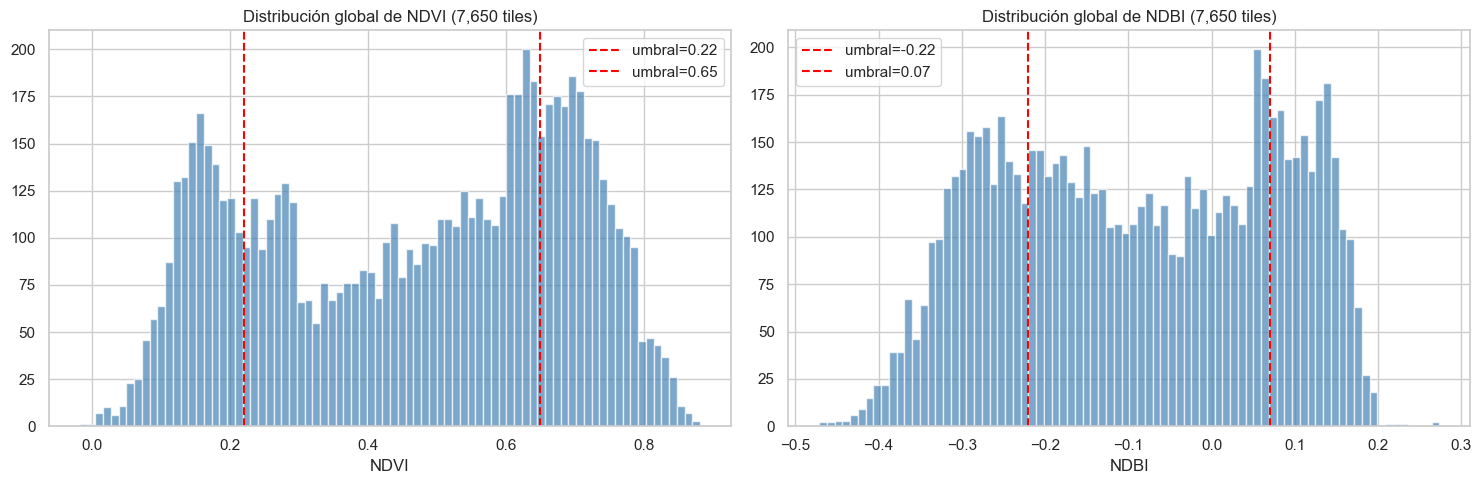


=== Percentiles empíricos (sobre 7,650 tiles consolidados) ===
NDVI  | p15=0.180 | p20=0.216 | p50=0.503 | p80=0.685 | p85=0.708
NDBI  | p15=-0.281 | p20=-0.257 | p50=-0.092 | p80=0.079 | p85=0.103


In [25]:
todos_tiles = pd.concat([df_orig[['clase','ndvi','ndbi']], df_v3[['clase','ndvi','ndbi']], df_rescate[['clase','ndvi','ndbi']]], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, var, umbrales in [
    (axes[0], 'ndvi', [0.22, 0.65]),
    (axes[1], 'ndbi', [-0.22, 0.07]),
]:
    ax.hist(todos_tiles[var].dropna(), bins=80, color='steelblue', alpha=0.7)
    for u in umbrales:
        ax.axvline(u, ls='--', color='red', label=f'umbral={u}')
    ax.set_title(f'Distribución global de {var.upper()} ({len(todos_tiles):,} tiles)')
    ax.set_xlabel(var.upper())
    ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'rangos_ndvi_ndbi.png', dpi=140, bbox_inches='tight')
plt.show()

# Percentiles empíricos
print('\n=== Percentiles empíricos (sobre 7,650 tiles consolidados) ===')
for var in ['ndvi','ndbi']:
    s = todos_tiles[var].dropna()
    print(f'{var.upper():5s} | p15={s.quantile(0.15):.3f} | p20={s.quantile(0.20):.3f} | p50={s.quantile(0.50):.3f} | p80={s.quantile(0.80):.3f} | p85={s.quantile(0.85):.3f}')

### 7.5 Validación de umbrales: los tiles del rescate quedaron dentro de su rango

Verifico que cada clase del rescate cumple los rangos NDVI/NDBI que definí:

In [26]:
rangos_clase = {
    'suelo_urbano':            {'ndvi_max': 0.22, 'ndbi_min': 0.07},
    'vegetacion_densa':        {'ndvi_min': 0.65, 'ndbi_max': -0.22},
    'contaminacion_alta_NO2':  {'ndvi_min': 0.15, 'ndvi_max': 0.50, 'ndbi_min': -0.10},
    'contaminacion_alta_SO2':  {'ndbi_min': -0.22, 'ndvi_max': 0.65},
    'ozono_anomalo':           {'ndvi_min': 0.20, 'ndvi_max': 0.60},
}

print('=== Verificación umbrales por clase en rescate-1500 ===')
print(f"{'clase':30s} | {'ndvi rango':25s} | {'ndbi rango':25s} | {'dentro?':10s}")
print('-' * 100)
for clase, rangos in rangos_clase.items():
    sub = df_rescate[df_rescate.clase == clase]
    cumple = pd.Series([True]*len(sub), index=sub.index)
    for k, v in rangos.items():
        if k == 'ndvi_min':
            cumple = cumple & (sub.ndvi >= v)
        elif k == 'ndvi_max':
            cumple = cumple & (sub.ndvi <= v)
        elif k == 'ndbi_min':
            cumple = cumple & (sub.ndbi >= v)
        elif k == 'ndbi_max':
            cumple = cumple & (sub.ndbi <= v)
    ndvi_str = f'[{sub.ndvi.min():.2f}, {sub.ndvi.max():.2f}]'
    ndbi_str = f'[{sub.ndbi.min():.2f}, {sub.ndbi.max():.2f}]'
    print(f'{clase:30s} | {ndvi_str:25s} | {ndbi_str:25s} | {cumple.sum()}/{len(sub)}')

=== Verificación umbrales por clase en rescate-1500 ===
clase                          | ndvi rango                | ndbi rango                | dentro?   
----------------------------------------------------------------------------------------------------
suelo_urbano                   | [0.03, 0.21]              | [0.08, 0.20]              | 300/300
vegetacion_densa               | [0.67, 0.84]              | [-0.39, -0.22]            | 300/300
contaminacion_alta_NO2         | [0.18, 0.47]              | [-0.10, 0.11]             | 300/300
contaminacion_alta_SO2         | [0.35, 0.65]              | [-0.22, 0.06]             | 300/300
ozono_anomalo                  | [0.29, 0.60]              | [-0.29, 0.10]             | 300/300


## 8. Cobertura del rescate-1500

Caracterización final del dataset elegido para Sit 2:
- N tiles total
- Distribución por clase
- Rango espacial (lat/lon)
- Rango temporal
- Buffer DAGMA respetado (para LOO-CV honesto)

In [27]:
if 'fecha_s2' in df_rescate.columns:
    df_rescate['_fecha'] = pd.to_datetime(df_rescate['fecha_s2'])
else:
    df_rescate['_fecha'] = pd.to_datetime(df_rescate.time_s2.astype(str).str.slice(0,8), format='%Y%m%d', errors='coerce')

# Buffer DAGMA: cuántos tiles caen cerca de estaciones
BUFFER = 0.005
def cerca_dagma(lat, lon):
    d = np.sqrt((df_est.latitud - lat)**2 + (df_est.longitud - lon)**2)
    return (d < BUFFER).any()

df_rescate['cerca_dagma'] = df_rescate.apply(lambda r: cerca_dagma(r.lat, r.lon), axis=1)

print(f'=== Rescate-1500 — caracterización final ===')
print(f'N total:        {len(df_rescate)}')
print(f'Por clase:      {df_rescate.clase.value_counts().to_dict()}')
print(f'Rango lat:      {df_rescate.lat.min():.4f} → {df_rescate.lat.max():.4f}')
print(f'Rango lon:      {df_rescate.lon.min():.4f} → {df_rescate.lon.max():.4f}')
print(f'Rango temporal: {df_rescate._fecha.min()} → {df_rescate._fecha.max()}')
print(f'Fechas únicas:  {df_rescate._fecha.dt.date.nunique()}')
print(f'Distrib año:    {df_rescate._fecha.dt.year.value_counts().sort_index().to_dict()}')
print(f'Cerca DAGMA (buffer 0.005°): {df_rescate.cerca_dagma.sum()}/{len(df_rescate)} ({df_rescate.cerca_dagma.mean():.1%})')

=== Rescate-1500 — caracterización final ===
N total:        1500
Por clase:      {'contaminacion_alta_NO2': 300, 'contaminacion_alta_SO2': 300, 'ozono_anomalo': 300, 'vegetacion_densa': 300, 'suelo_urbano': 300}
Rango lat:      3.3029 → 3.6246
Rango lon:      -76.6455 → -76.3029
Rango temporal: 2021-01-16 00:00:00 → 2025-12-31 00:00:00
Fechas únicas:  75
Distrib año:    {2021: 164, 2022: 253, 2023: 262, 2024: 662, 2025: 159}
Cerca DAGMA (buffer 0.005°): 58/1500 (3.9%)


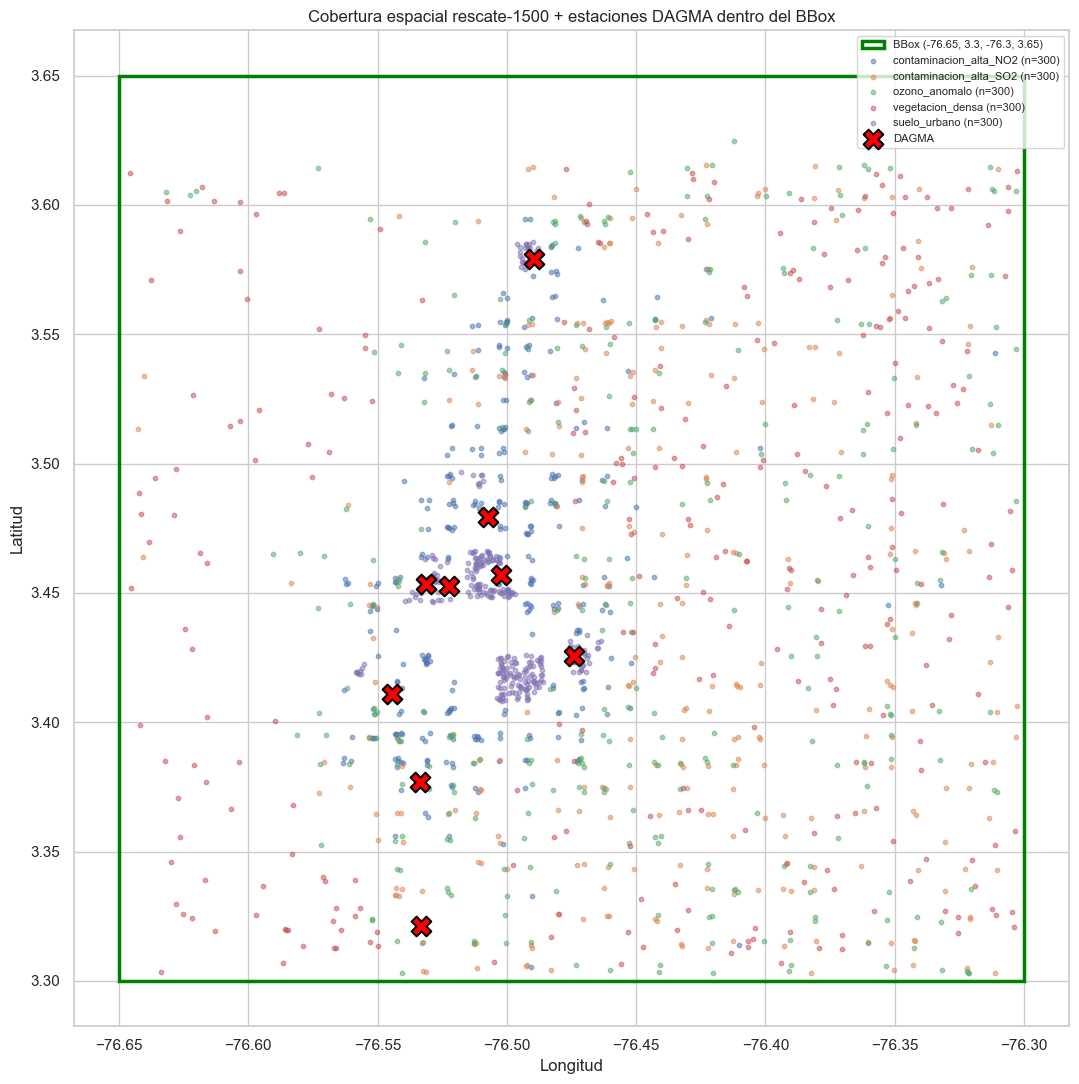

In [28]:
fig, ax = plt.subplots(figsize=(11, 11))
ax.add_patch(Rectangle((lon_min, lat_min), lon_max-lon_min, lat_max-lat_min,
                       fill=False, edgecolor='green', linewidth=2.5, label=f'BBox {BBOX}'))
for c in df_rescate.clase.unique():
    sub = df_rescate[df_rescate.clase == c]
    ax.scatter(sub.lon, sub.lat, s=10, alpha=0.5, label=f'{c} (n={len(sub)})')
ax.scatter(df_est.longitud, df_est.latitud, marker='X', c='red', s=200,
           edgecolor='black', linewidth=1.5, label='DAGMA', zorder=5)
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.set_title('Cobertura espacial rescate-1500 + estaciones DAGMA dentro del BBox')
ax.legend(fontsize=8); ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(OUT / 'rescate_cobertura_espacial.png', dpi=140, bbox_inches='tight')
plt.show()

### 8.5 Ventana temporal: ¿qué se usa en Sit 2 y qué en Sit 3?

| componente | rango usado | razón |
|------------|-------------|-------|
| **Sit 1** (panel cloud) | 2021-01 → 2026-01 | 5 años PDF |
| **Sit 2** (CLIP + SAE retrieval) | **2021-2025** (1500 tiles, incluye 159 de 2025) | retrieval imagen-texto, no requiere ground truth temporal |
| **Sit 3** (LOO-CV + Kriging) | **2021-2024** (overlap DAGMA) | DAGMA publica hasta 2024-12-31 |

Los 159 tiles de 2025 quedan **fuera de Sit 3** automáticamente (el notebook Sit 3 filtra `dagma.fecha <= 2024-12-31` y los embeddings se generan solo para fechas DAGMA). No es desperdicio: aportan diversidad al entrenamiento Sit 2.

In [29]:
ventana = df_rescate.groupby(df_rescate._fecha.dt.year).size()
print('=== Distribución temporal de los 1500 tiles ===')
for anio, n in ventana.items():
    usado_sit2 = '✓' if anio >= 2021 else '-'
    usado_sit3 = '✓' if 2021 <= anio <= 2024 else '✗ (sin DAGMA)'
    print(f'  {anio} | n={n:4d} | Sit 2: {usado_sit2} | Sit 3: {usado_sit3}')

print(f'\nTotal usable Sit 3 (2021-2024): {ventana.loc[2021:2024].sum()}/{len(df_rescate)}')
print(f'Tiles 2025 (solo Sit 2):       {ventana.get(2025, 0)}/{len(df_rescate)}')

=== Distribución temporal de los 1500 tiles ===
  2021 | n= 164 | Sit 2: ✓ | Sit 3: ✓
  2022 | n= 253 | Sit 2: ✓ | Sit 3: ✓
  2023 | n= 262 | Sit 2: ✓ | Sit 3: ✓
  2024 | n= 662 | Sit 2: ✓ | Sit 3: ✓
  2025 | n= 159 | Sit 2: ✓ | Sit 3: ✗ (sin DAGMA)

Total usable Sit 3 (2021-2024): 1341/1500
Tiles 2025 (solo Sit 2):       159/1500


## 9. Resumen ejecutivo

Tabla consolidada para citar en el informe técnico:

In [30]:
resumen = {
    'bbox': list(BBOX),
    'dagma': {
        'estaciones_total': int(df_est.en_bbox.sum()),
        'estaciones_por_gas': df_dagma.groupby('tipo_gas').nombre_est.nunique().to_dict(),
        'obs_horarias': int(len(df_dagma)),
        'cobertura_temporal_anios': round((df_dagma.fecha.max()-df_dagma.fecha.min()).days/365.25, 2),
    },
    'sentinel5p': {
        'no2_obs': int(len(fechas_no2)),
        'so2_obs': int(len(fechas_so2)),
        'o3_obs':  int(len(fechas_o3)),
    },
    'era5': {
        'horas': int(len(fechas_era5)),
        'anios': round(len(fechas_era5)/24/365.25, 2),
        'bandas': BANDAS_ERA5,
    },
    'tiles_separabilidad': scores_df.to_dict(orient='records'),
    'tiles_separabilidad_ext': scores_ext_df.to_dict(orient='records'),
    'rescate_1500': {
        'n_total': int(len(df_rescate)),
        'n_por_clase': df_rescate.clase.value_counts().to_dict(),
        'fechas_unicas': int(df_rescate._fecha.dt.date.nunique()),
        'pct_cerca_dagma': float(df_rescate.cerca_dagma.mean()),
    },
}
with open(OUT / 'eda_resumen.json', 'w', encoding='utf-8') as f:
    json.dump(resumen, f, ensure_ascii=False, indent=2, default=str)

print(json.dumps(resumen, ensure_ascii=False, indent=2, default=str))

{
  "bbox": [
    -76.65,
    3.3,
    -76.3,
    3.65
  ],
  "dagma": {
    "estaciones_total": 9,
    "estaciones_por_gas": {
      "no2": 2,
      "o3": 7,
      "so2": 5
    },
    "obs_horarias": 300025,
    "cobertura_temporal_anios": 4.0
  },
  "sentinel5p": {
    "no2_obs": 25592,
    "so2_obs": 25829,
    "o3_obs": 25716
  },
  "era5": {
    "horas": 43824,
    "anios": 5.0,
    "bandas": [
      "T2m",
      "Td2m",
      "u10",
      "v10",
      "BLH",
      "RH850",
      "psurf",
      "precip"
    ]
  },
  "tiles_separabilidad": [
    {
      "dataset": "rescate-1500",
      "silhouette": 0.282,
      "rf_acc": 0.796
    },
    {
      "dataset": "originales (5000)",
      "silhouette": -0.023,
      "rf_acc": 0.503
    },
    {
      "dataset": "v3 (1150)",
      "silhouette": 0.033,
      "rf_acc": 0.526
    }
  ],
  "tiles_separabilidad_ext": [
    {
      "dataset": "rescate-1500",
      "n_feats": 8,
      "silhouette_ext": 0.055,
      "rf_acc_ext": 0.844
    },
  